# **DATA EXPLORATION**

---

## **A. Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from data_exploration.hotel import (
    plot_price_distribution,
    visualize_review_score,
    visualize_ratings,
    visualize_physical_attributes,
    visualize_amenities,
    analyze_amenity_price_relation,
    analyze_categorical_text,
    analyze_pricing_strategy,
    analyze_location_accessibility,
    analyze_categorical_data
)

## **B. Hotels data**

### **1. Hotel Attributes & Amenities**

#### **1.1 Load Raw Data**

Trong giai đoạn đầu của quá trình khám phá dữ liệu về tổng quan Khách sạn và Tiện ích, chúng em tiến hành tải dữ liệu thô (raw data) từ hai tệp CSV đã thu thập được trong thư mục `data/raw`.

In [2]:
hotel_path = "../data/raw/hotels_list.csv"
facilities_path = "../data/raw/facilities_list.csv"
df_hotels = pd.read_csv(hotel_path)
df_fac = pd.read_csv(facilities_path)

#### **1.2 Basic Information**

Dữ liệu khách sạn được đọc từ tệp `hotels_list.csv` và được lưu vào biến `df_hotels`; dữ liệu về các tiện nghi của khách sạn được đọc từ tệp `facilities_list.csv` và được lưu vào biến `df_fac`. Để có cái nhìn ban đầu về cấu trúc và đặc điểm của dataset, chúng em hiển thị 5 dòng đầu tiên và 5 dòng cuối cùng.

In [3]:
# Xem 5 dòng đầu
df_hotels.head()

,Hotel_ID,Hotel_Name,Property_Type,Star_Rating,Review_Score,Review_Count,Facilities_Count,Has_Pool,Room_Size_Sqm,City,...,Group_Location,Group_Overall,Group_Staff,Group_Value,Solo_Cleanliness,Solo_Facilities,Solo_Location,Solo_Overall,Solo_Staff,Solo_Value
0,58578022,Orchide'es Ocean Hotel,NormalProperty,4.0,8.6,99,0,0,25.0,Da Nang,...,10.0,9.2,10.0,8.0,10.0,8.0,10.0,9.2,10.0,8.0
1,44325456,Song Cat Villa - 59NL,NormalProperty,4.0,9.6,55,0,0,250.0,Da Nang,...,NaN,NaN,NaN,NaN,5.0,6.0,8.0,6.8,6.0,9.0
2,238037,VINH TRUNG PLAZA HOTEL,NormalProperty,4.0,6.9,401,0,0,50.0,Da Nang,...,7.9,6.8,7.1,6.8,6.4,6.0,8.2,7.0,7.3,7.2
3,7446249,Perfect Private Pool Villa,NormalProperty,4.0,8.7,7,0,0,NaN,Da Nang,...,8.0,6.4,8.0,4.0,8.7,8.0,8.7,8.3,7.3,8.7
4,30653737,Le Sands Oceanfront Danang Hotel,NormalProperty,4.0,9.1,9476,0,0,42.0,Da Nang,...,8.8,9.3,9.6,9.5,9.5,9.2,8.8,9.3,9.5,9.5


In [4]:
# Xem 5 dòng cuối
df_hotels.tail()

,Hotel_ID,Hotel_Name,Property_Type,Star_Rating,Review_Score,Review_Count,Facilities_Count,Has_Pool,Room_Size_Sqm,City,...,Group_Location,Group_Overall,Group_Staff,Group_Value,Solo_Cleanliness,Solo_Facilities,Solo_Location,Solo_Overall,Solo_Staff,Solo_Value
491,46296708,My Hotel,NormalProperty,1.0,8.6,1260,0,0,18.0,Ho Chi Minh City,...,9.0,8.8,8.0,9.0,10.0,10.0,10.0,10.0,10.0,10.0
492,65284420,Panda Garden Hotel and Apartment,NormalProperty,0.0,9.4,136,0,0,28.0,Ho Chi Minh City,...,NaN,NaN,NaN,NaN,10.0,10.0,10.0,10.0,10.0,10.0
493,26079619,Thuong Hai Hotel,NormalProperty,1.0,7.5,190,0,0,15.0,Ho Chi Minh City,...,6.0,7.2,8.0,6.0,6.0,6.0,8.0,6.8,6.7,7.3
494,4961316,Gemini Saigon LUXURY,NormalProperty,1.0,7.5,1917,0,0,25.0,Ho Chi Minh City,...,6.8,7.4,7.2,8.0,8.5,7.5,9.3,8.4,8.3,8.2
495,60764910,Suzu Saigon - A Boutique Hotel,NormalProperty,4.0,9.0,669,0,0,30.0,Ho Chi Minh City,...,10.0,10.0,10.0,10.0,10.0,8.0,10.0,9.6,10.0,10.0


In [5]:
# Xem 5 dòng đầu
df_fac.head()

,hotel_id,hotel_name,group_name,facility_id,facility_name
0,2987297,TROPICAL VILLA,Take a look at these facilities:,68,Garden
1,2987297,TROPICAL VILLA,Take a look at these facilities:,61,Spa
2,2987297,TROPICAL VILLA,Take a look at these facilities:,65,Swimming pool [outdoor]
3,2987297,TROPICAL VILLA,Take a look at these facilities:,288,Kitchen
4,2987297,TROPICAL VILLA,Take a look at these facilities:,11,Restaurants


In [6]:
# Xem 5 dòng cuối
df_fac.tail()

,hotel_id,hotel_name,group_name,facility_id,facility_name
42708,8776438,Tina Hotel & Apartments _ The Diamond Oasis,Available in all rooms,232,Closet
42709,8776438,Tina Hotel & Apartments _ The Diamond Oasis,Available in all rooms,210,Clothes rack
42710,8776438,Tina Hotel & Apartments _ The Diamond Oasis,Available in all rooms,338,Private bathroom
42711,8776438,Tina Hotel & Apartments _ The Diamond Oasis,Available in all rooms,39,Separate shower/bathtub
42712,8776438,Tina Hotel & Apartments _ The Diamond Oasis,Available in all rooms,35,TV


**Tính số dòng, số cột của dữ liệu**

In [7]:
num_rows_df_hotels, num_cols_df_hotels = df_hotels.shape
print(f"Number of rows (hotels list): {num_rows_df_hotels}")
print(f"Number of columns (hotels list): {num_cols_df_hotels}")

Number of rows (hotels list): 496
Number of columns (hotels list): 64


In [8]:
num_rows_df_fac, num_cols_df_fac = df_fac.shape
print(f"Number of rows (facilities list): {num_rows_df_fac}")
print(f"Number of columns (facilities list): {num_cols_df_fac}")

Number of rows (facilities list): 42713
Number of columns (facilities list): 5


Bộ dữ liệu khách sạn tổng quát được thu thập bao gồm hai nguồn chính.

File `hotels_list.csv` chứa thông tin tổng quan về 496 khách sạn với 66 thuộc tính, bao gồm các đặc trưng cơ bản như tên khách sạn, loại hình, xếp hạng sao, điểm đánh giá, số lượng đánh giá, số lượng tiện nghi, các tiện nghi chính, diện tích phòng, vị trí địa lý (thành phố, khu vực, tọa độ), khoảng cách đến các điểm mốc như trung tâm, bãi biển, trạm giao thông, cũng như các thông tin liên quan đến giá cả, chính sách hủy phòng, và đánh giá chi tiết theo các nhóm khách hàng (Couples, Family, Group, Solo).

File `facilities_list.csv` ghi nhận chi tiết các tiện nghi của từng khách sạn, bao gồm 42,713 bản ghi với 5 cột: `hotel_id`, `hotel_name`, `group_name`, `facility_id`, và `facility_name`. Dữ liệu này phản ánh sự đa dạng và phong phú của các tiện nghi tại mỗi cơ sở lưu trú.

Tổng quan, bộ dữ liệu cung cấp một cái nhìn toàn diện về cả khách sạn và tiện nghi kèm theo, đồng thời có cấu trúc đủ chi tiết để thực hiện các phân tích định lượng về giá phòng, sự đa dạng tiện nghi, và mối quan hệ giữa các đặc trưng vật lý, vị trí và trải nghiệm khách hàng.

#### **1.3 Data Integrity**

**Checking duplicated data**

Để đảm bảo tính toàn vẹn của tập dữ liệu, chúng em đã tiến hành kiểm tra toàn diện các bản ghi trùng lặp trên tất cả các thuộc tính bằng phương pháp `duplicated` trong Pandas với tham số `keep = False`. Phương pháp này giúp xác định bất kỳ hàng nào hoàn toàn giống nhau về tất cả các đặc trưng.

In [9]:
duplicated_hotels = df_hotels.duplicated(keep = False)
print(duplicated_hotels.any())

False


In [10]:
duplicated_fac = df_fac.duplicated(keep = False)
print(duplicated_fac.any())

False


Kết quả kiểm tra cho thấy không có bản ghi nào bị trùng lặp trong cả hai tập dữ liệu.

**Percentage of missing values**

Để đánh giá chất lượng dữ liệu ta tiến hành kiểm tra tỷ lệ giá trị thiếu trong toàn bộ các cột của hai tập dữ liệu `df_hotels` và `df_fac`

In [11]:
def missing_percentage(df):
    num_rows = df.shape[0]
    for col_name in df.columns:
        if df[col_name].dtype == object:
            missing_count = df[col_name].isna().sum() + (df[col_name] == "").sum()
        else:
            missing_count = df[col_name].isna().sum()
        missing_percent = (missing_count / num_rows) * 100
        print(f"{col_name:40}: {missing_percent:.2f}%")

In [12]:
print("Missing Values in Hotels")
missing_percentage(df_hotels)

Missing Values in Hotels
Hotel_ID                                : 0.00%
Hotel_Name                              : 0.00%
Property_Type                           : 0.00%
Star_Rating                             : 0.00%
Review_Score                            : 0.00%
Review_Count                            : 0.00%
Facilities_Count                        : 0.00%
Has_Pool                                : 0.00%
Room_Size_Sqm                           : 6.05%
City                                    : 0.00%
Area                                    : 0.00%
Latitude                                : 0.00%
Longitude                               : 0.00%
Distance_Center                         : 0.00%
Near_Public_Transport                   : 0.00%
Nearest_Transport_Name                  : 29.44%
Nearest_Transport_Dist                  : 29.44%
Nearest_Beach_Name                      : 30.24%
Nearest_Beach_Dist                      : 30.24%
Nearest_Landmark_Name                   : 1.01%
Nearest_Lan

In [13]:
print("\nMissing Values in Facilities")
missing_percentage(df_fac)


Missing Values in Facilities
hotel_id                                : 0.00%
hotel_name                              : 0.00%
group_name                              : 0.00%
facility_id                             : 0.00%
facility_name                           : 0.00%


Kết quả cho thấy hầu hết các thông tin cơ bản của khách sạn như `Hotel_ID, Hotel_Name, Property_Type, Star_Rating, Review_Score, Review_Count, Facilities_Count, City, Area, Latitude, Longitude, Distance_Center, Near_Public_Transport, Is_Available, Free_Cancel, Free_Breakfast, Pay_Later, Pay_At_Hotel, People_Looking, Last_Booking` đều đầy đủ, với tỷ lệ missing bằng 0%.

Tuy nhiên, một số cột gặp tỷ lệ thiếu đáng kể. Điển hình, cột Key_Facilities và Room_Type bị thiếu hoàn toàn (100%). Tuy nhiên, việc thiếu dữ liệu trong cột Key_Facilities được giải thích do thông tin này được lưu giữ trong tập dữ liệu `df_fac`, nơi mỗi khách sạn có danh sách các cơ sở vật chất chi tiết. Và cột Room_Type cũng được thu thập trong tập df_rooms, cho phép nối về df_hotels để hoàn thiện thông tin về loại phòng. Các cột liên quan đến khuyến mãi (Promotion_Tag, Promotion_Type_ID) thiếu khoảng 80%. Thông tin vị trí và khoảng cách đến điểm tham quan, bãi biển (Nearest_Transport_Name, Nearest_Transport_Dist, Nearest_Beach_Name, Nearest_Beach_Dist) cũng có tỷ lệ missing từ 29% đến 30%.

Các cột đánh giá trải nghiệm của nhóm khách khác nhau (Couples, Family_Older, Family_Young, Group, Solo) đều có tỷ lệ missing từ 13% đến 37%, đặc biệt là đánh giá từ Family_Young (từ 36.9% đến 37.1%) và nhóm Group (34.88%). Các đánh giá từ khách đi một mình (Solo) thiếu khoảng 21%, trong khi các đánh giá từ Couples và Family_Older thiếu từ 13% đến 17%.

Một số thông tin giá cả (Price_Display, Price_Original, Currency) thiếu khoảng 1.4%.

Nhìn chung, dữ liệu cơ bản của khách sạn có chất lượng tốt, trong khi các thông tin chi tiết về cơ sở vật chất, loại phòng, khuyến mãi và đánh giá khách thiếu đáng kể. Tuy nhiên, nhờ sự phân tách dữ liệu thành các tập df_facilities và df_rooms, các thông tin này có thể được kết hợp và khôi phục, nâng cao chất lượng dữ liệu trước các bước phân tích hoặc mô hình hóa.

#### **1.4 Data Semantics**

**The meaning of each row**

Mỗi dòng trong bộ dữ liệu `df_hotels` đại diện cho một khách sạn riêng lẻ. Một hàng chứa toàn bộ thông tin tổng quan về khách sạn đó, bao gồm định danh, vị trí, cơ sở vật chất, loại phòng, giá cả, khuyến mãi, và đánh giá của khách hàng theo nhiều nhóm khác nhau (couples, family, group, solo). Do đó, mỗi row tương ứng với một thực thể khách sạn duy nhất, cho phép phân tích đặc điểm, chất lượng dịch vụ, và trải nghiệm của khách.

Mỗi dòng trong bộ dữ liệu `df_fac` đại diện cho một cơ sở vật chất (facility) cụ thể của một khách sạn. Một khách sạn có thể có nhiều hàng trong tập này, tương ứng với từng tiện ích riêng biệt. Cột hotel_id và hotel_name liên kết với khách sạn trong df_hotels, trong khi facility_id và facility_name xác định duy nhất từng cơ sở vật chất. Như vậy, mỗi row trong df_facilities phản ánh một dịch vụ hoặc tiện nghi cụ thể của khách sạn, giúp bổ sung thông tin chi tiết mà cột Key_Facilities trong df_hotels không thể lưu trữ đầy đủ.

**The meaning of each column**

In [14]:
df_hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 64 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hotel_ID                  496 non-null    int64  
 1   Hotel_Name                496 non-null    object 
 2   Property_Type             496 non-null    object 
 3   Star_Rating               496 non-null    float64
 4   Review_Score              496 non-null    float64
 5   Review_Count              496 non-null    int64  
 6   Facilities_Count          496 non-null    int64  
 7   Has_Pool                  496 non-null    int64  
 8   Room_Size_Sqm             466 non-null    float64
 9   City                      496 non-null    object 
 10  Area                      496 non-null    object 
 11  Latitude                  496 non-null    float64
 12  Longitude                 496 non-null    float64
 13  Distance_Center           496 non-null    float64
 14  Near_Publi

Mỗi cột trong bộ dữ liệu thể hiện một nhóm thông tin cấu trúc hoặc chức năng mô tả đặc điểm cho một khách sạn riêng lẻ.

* Định danh và mô tả cơ bản: `Hotel_ID`, `Hotel_Name`, `Property_Type`, `Star_Rating`.
* Đánh giá khách hàng: `Review_Score`, `Review_Count`, các cột đánh giá chi tiết theo nhóm khách (`Couples_Cleanliness`, `Family_Older_Overall`, `Solo_Value`, …).
* Thông tin cơ sở vật chất và phòng: `Facilities_Count`, `Key_Facilities`, `Has_Pool`, `Room_Size_Sqm`, `Room_Type`.
* Vị trí và khoảng cách: `City`, `Area`, `Latitude`, `Longitude`, `Distance_Center`, `Near_Public_Transport`, `Nearest_Transport_Name`, `Nearest_Transport_Dist`, `Nearest_Beach_Name`, `Nearest_Beach_Dist`, `Nearest_Landmark_Name`, `Nearest_Landmark_Dist`.
* Thông tin khuyến mãi và giá: `Promotion_Tag`, `Promotion_Type_ID`, `Price_Display`, `Price_Original`, `Discount_Percent`, `Currency`.
* Tùy chọn đặt phòng và chính sách: `Free_Cancel`, `Free_Breakfast`, `Pay_Later`, `Pay_At_Hotel`, `Is_Available`, `People_Looking`, `Last_Booking`.

In [15]:
df_fac.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42713 entries, 0 to 42712
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   hotel_id       42713 non-null  int64 
 1   hotel_name     42713 non-null  object
 2   group_name     42713 non-null  object
 3   facility_id    42713 non-null  int64 
 4   facility_name  42713 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.6+ MB


Mỗi cột trong bộ dữ liệu `df_facilities` thể hiện đại diện cho thông tin về cơ sở vật chất (facility) cụ thể của một khách sạn.
* Khách sạn liên kết: `hotel_id`, `hotel_name`.
* Nhóm cơ sở vật chất: `group_name`.
* Thông tin tiện ích: `facility_id`, `facility_name`.

**Column Data Types and Compatibility for Analysis**

In [16]:
for col in df_hotels.columns:
    col_type = df_hotels[col].dtype
    print(f"{col:25} Type: {col_type}")

Hotel_ID                  Type: int64
Hotel_Name                Type: object
Property_Type             Type: object
Star_Rating               Type: float64
Review_Score              Type: float64
Review_Count              Type: int64
Facilities_Count          Type: int64
Has_Pool                  Type: int64
Room_Size_Sqm             Type: float64
City                      Type: object
Area                      Type: object
Latitude                  Type: float64
Longitude                 Type: float64
Distance_Center           Type: float64
Near_Public_Transport     Type: bool
Nearest_Transport_Name    Type: object
Nearest_Transport_Dist    Type: float64
Nearest_Beach_Name        Type: object
Nearest_Beach_Dist        Type: float64
Nearest_Landmark_Name     Type: object
Nearest_Landmark_Dist     Type: float64
Is_Available              Type: bool
Promotion_Tag             Type: object
Promotion_Type_ID         Type: float64
Price_Display             Type: float64
Price_Original        

Để đảm bảo dữ liệu phù hợp cho các bước phân tích và mô hình hóa, ta tiến hành kiểm tra kiểu dữ liệu của từng cột trong tập dữ liệu khách sạn `df_hotels`. Kết quả cho thấy các cột được phân loại hợp lý theo loại dữ liệu, phản ánh đúng bản chất thông tin mà chúng chứa.

* Cột định danh và số lượng: Các cột như `Hotel_ID`, `Review_Count`, `Facilities_Count`, `Has_Pool`, `People_Looking` có kiểu số nguyên (`int64`), phù hợp cho các phân tích định lượng và thống kê.
* Cột mô tả dạng văn bản: `Hotel_Name`, `Property_Type`, `City`, `Area`, `Nearest_Transport_Name`, `Nearest_Beach_Name`, `Nearest_Landmark_Name`, `Promotion_Tag`, `Currency` và `Last_Booking` đều có kiểu `object`, phản ánh dữ liệu dạng chuỗi và văn bản, thích hợp cho phân tích phân loại hoặc tiền xử lý dạng text.
* Cột số thực: Các cột liên quan đến đánh giá khách hàng (`Review_Score`, `Couples_Cleanliness`, `Family_Young_Overall`, v.v.), thông tin vị trí (`Latitude`, `Longitude`, `Distance_Center`, `Nearest_Transport_Dist`, `Nearest_Beach_Dist`, `Nearest_Landmark_Dist`) và giá cả (`Price_Display`, `Price_Original`, `Discount_Percent`) có kiểu số thực (`float64`), phù hợp cho các phân tích thống kê, tính toán khoảng cách, và mô hình hóa dự đoán.
* Cột logic: Các cột nhị phân hoặc boolean như `Near_Public_Transport`, `Is_Available`, `Free_Cancel`, `Free_Breakfast`, `Pay_Later`, `Pay_At_Hotel` có kiểu `bool`, thuận tiện cho phân loại hoặc tính toán xác suất.
* Cột đặc biệt với missing value: Cột `Key_Facilities` và `Room_Type` mặc dù hiện có kiểu `float64`, thực tế là trống hoàn toàn và cần được bổ sung từ các tệp dữ liệu liên quan (`df_facilities` và `df_rooms`).

Nhìn chung, cấu trúc kiểu dữ liệu của các cột trong `df_hotels` tương thích tốt với các phương pháp phân tích định lượng và phân loại. Các cột số và boolean có thể được sử dụng trực tiếp cho các mô hình thống kê hoặc machine learning, trong khi các cột dạng object sẽ cần tiền xử lý như one-hot encoding hoặc text embedding tùy thuộc vào mục tiêu phân tích.

In [17]:
for col in df_fac.columns:
    col_type = df_fac[col].dtype
    print(f"{col:25} Type: {col_type}")

hotel_id                  Type: int64
hotel_name                Type: object
group_name                Type: object
facility_id               Type: int64
facility_name             Type: object


Đối với tập dữ liệu cơ sở vật chất `df_facilities` kết quả cho thấy các cột được gán kiểu dữ liệu hợp lý với bản chất thông tin mà chúng chứa:

* Cột định danh: `hotel_id` và `facility_id` có kiểu số nguyên (`int64`), phù hợp cho việc xác định duy nhất khách sạn và cơ sở vật chất cũng như phục vụ cho các phép nối dữ liệu và thống kê.
* Cột mô tả dạng văn bản: `hotel_name`, `group_name` và `facility_name` có kiểu `object`, phản ánh dữ liệu dạng chuỗi, thích hợp cho phân loại, phân nhóm hoặc trích xuất thông tin từ tên cơ sở vật chất.

Như vậy, tập dữ liệu `df_facilities` có cấu trúc kiểu dữ liệu đơn giản, dễ sử dụng và tương thích với các phân tích định lượng lẫn phân loại. Các cột số nguyên cho phép thực hiện các phép thống kê, nối dữ liệu và tính toán, trong khi các cột dạng văn bản có thể được tiền xử lý nếu cần sử dụng cho các mô hình machine learning hoặc trích xuất thông tin chi tiết về cơ sở vật chất.

Việc kiểm tra kiểu dữ liệu này cũng giúp xác nhận rằng `df_facilities` có thể được liên kết trực tiếp với `df_hotels` thông qua cột `hotel_id` để bổ sung thông tin chi tiết về cơ sở vật chất cho từng khách sạn.

#### **1.5 Distribution & Visualization**

**Analysis of Numeric Columns**

**Nhóm đặc trưng về Chiến lược giá & Khuyến mãi `Price_Original`, `Price_Display`, `Discount_Percent`**

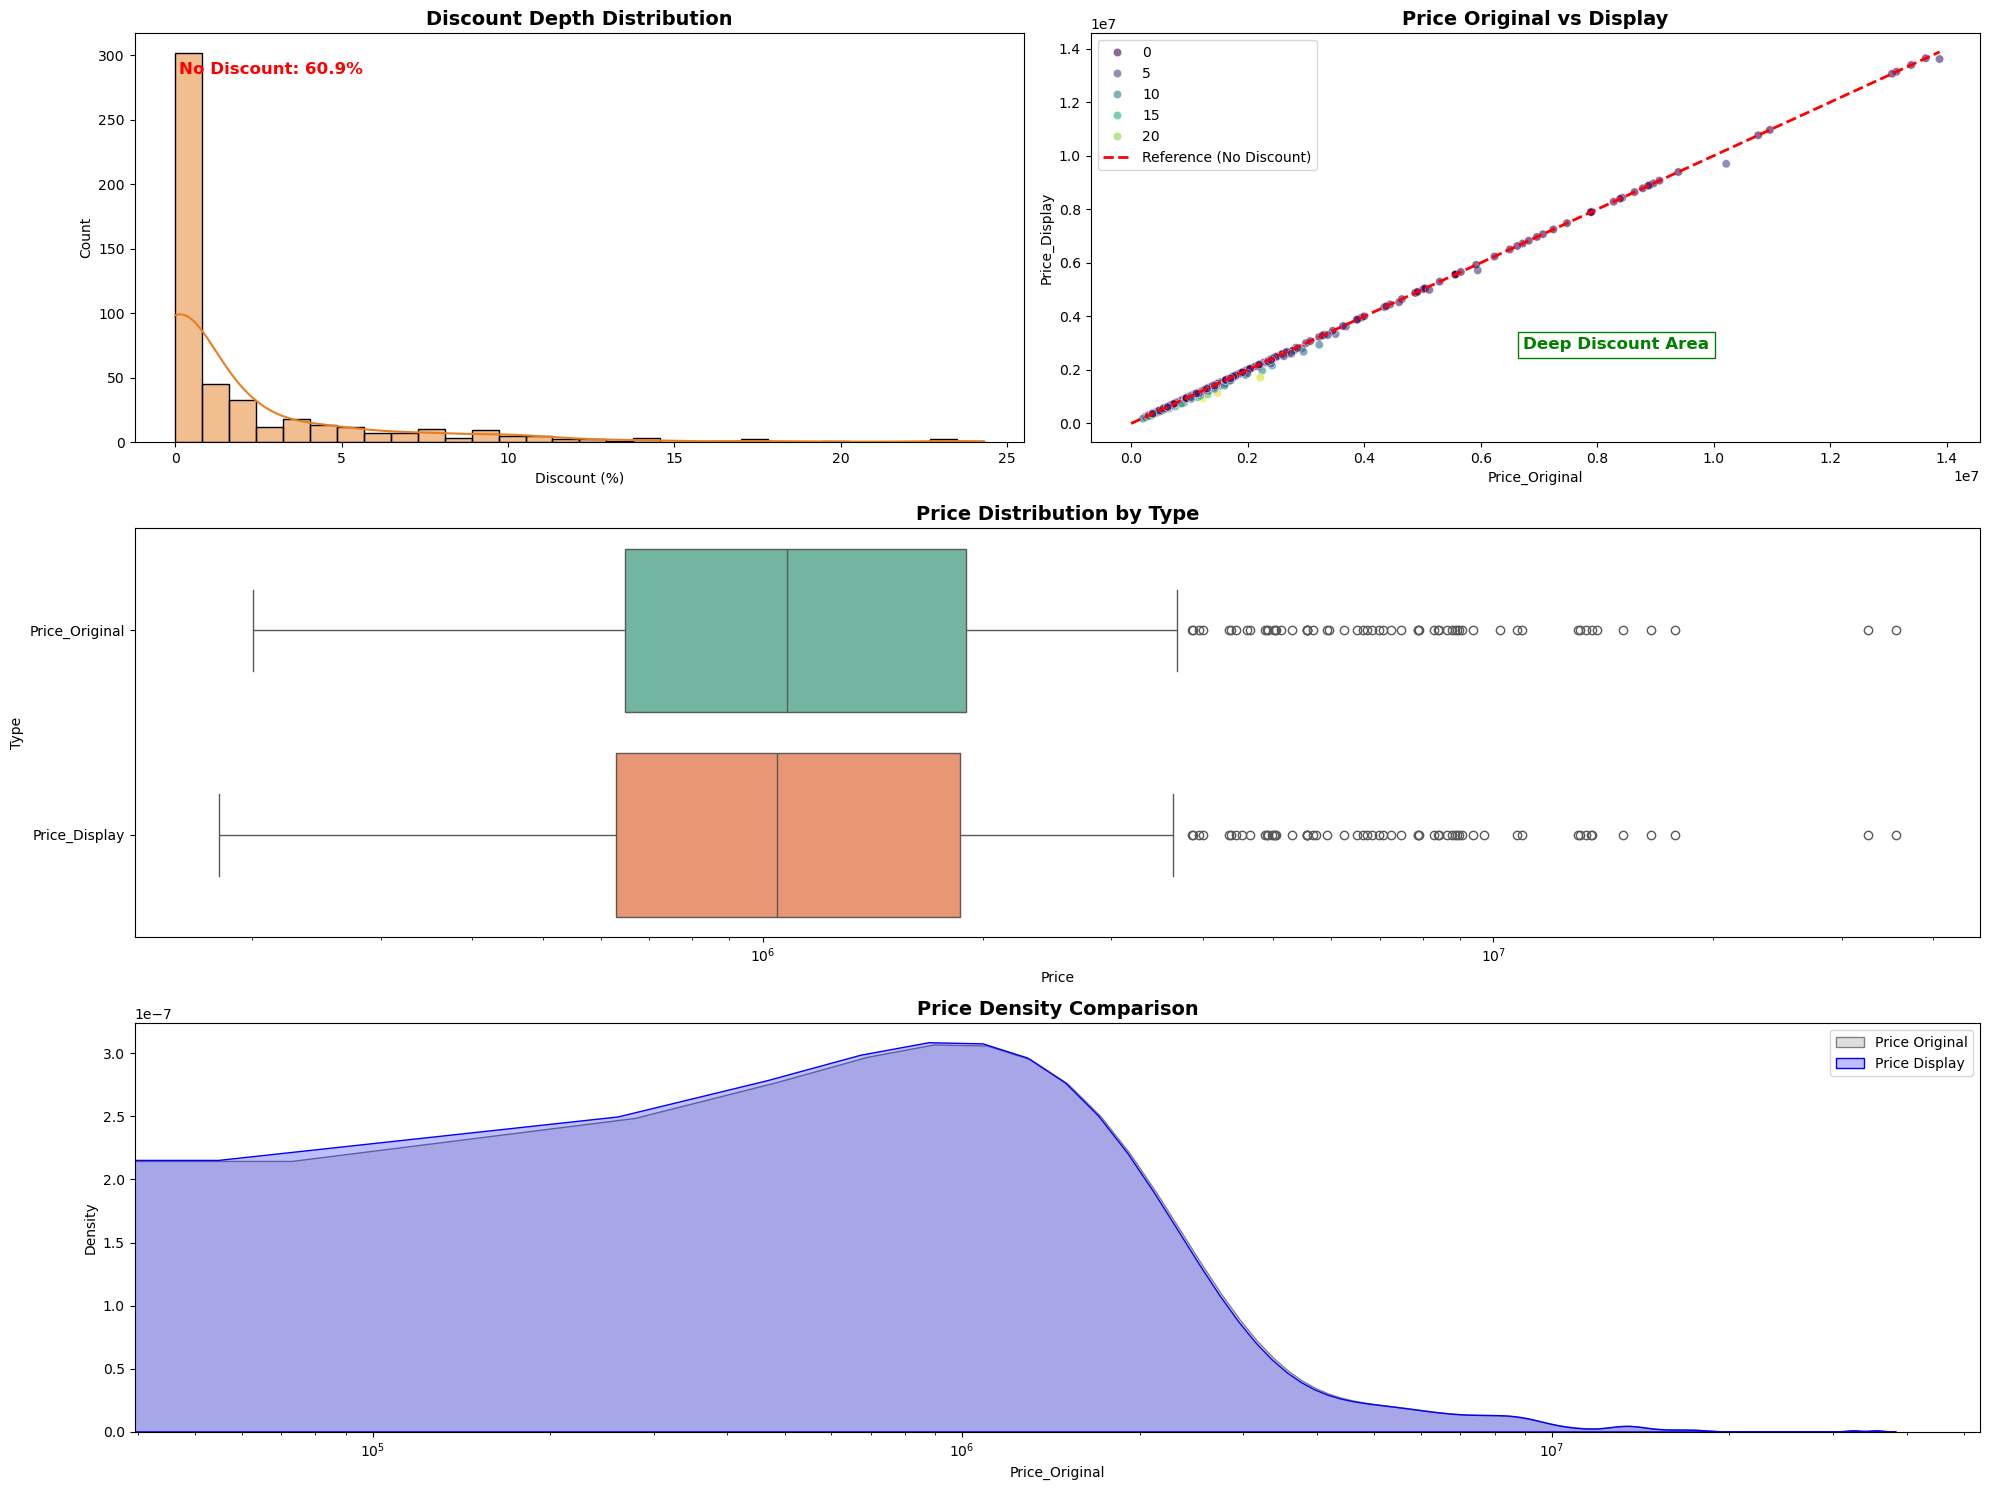

Discount Range: 0.0% -> 24.3%
No Discount Rooms: 60.9%
Max Display Price: 35,583,480 VND
Median Original Price: 1,079,801
Median Display Price: 1,046,520
Average Discount Percent: 1.97%


In [18]:
analyze_pricing_strategy(df_hotels)

Kết quả phân tích hành vi khuyến mãi cho thấy thị trường khách sạn được khảo sát vận hành theo một chiến lược định giá bảo thủ và ổn định. Đa số các cơ sở lưu trú (60,9%) duy trì mức giá niêm yết không giảm, trong khi mức giảm giá trung bình chỉ đạt 1,97%, với mức giảm tối đa ghi nhận được là 24,3%. Không xuất hiện các mức giảm sốc (>50% hoặc >70%), điều này phản ánh giai đoạn thu thập dữ liệu thuộc thời kỳ bình ổn giá hoặc thị trường ít áp dụng các chiêu thức kích cầu bằng giá sốc.

Mối quan hệ giữa giá gốc (`Price_Original`) và giá hiển thị (`Price_Display`) được biểu thị qua scatter plot cho thấy sự trùng khít gần như hoàn hảo ($y \approx x$), với hầu hết các điểm dữ liệu nằm sát đường 45 độ. Khu vực Deep Discount Area hầu như không xuất hiện, khẳng định rằng các mức giảm sâu là cực kỳ hiếm hoi. Sự trùng khớp này đồng thời cho thấy tính minh bạch cao trong niêm yết giá, không có bằng chứng về hành vi "nâng giá ảo" để tạo hiệu ứng giảm giá giả tạo.

Phân tích phân phối và mật độ giá bằng Boxplot và Density Plot ở thang đo Logarit cho thấy giá gốc và giá hiển thị gần như trùng khít. Trung vị giá gốc là 1,079,801 VND, trong khi trung vị giá hiển thị là 1,046,520 VND, chênh lệch chỉ khoảng 3,1%, phản ánh tác động của các chương trình khuyến mãi lên cấu trúc giá chung của thị trường là không đáng kể.

Từ đó ta có thể rút ra kết luận răng đối với người tiêu dùng, việc chờ đợi "giảm giá sâu" có thể không mang lại lợi ích đáng kể; đối với mô hình dự báo giá, cả hai biến Price_Display và Price_Original có thể sử dụng thay thế nhau do mức cộng tuyến cao giữa chúng, đảm bảo tính ổn định và độ chính xác trong các phân tích dự đoán giá phòng.

**Nhóm đặc trưng về Vị trí & Khoảng cách `Distance_Center, Nearest_Transport_Dist, Nearest_Beach_Dist`**

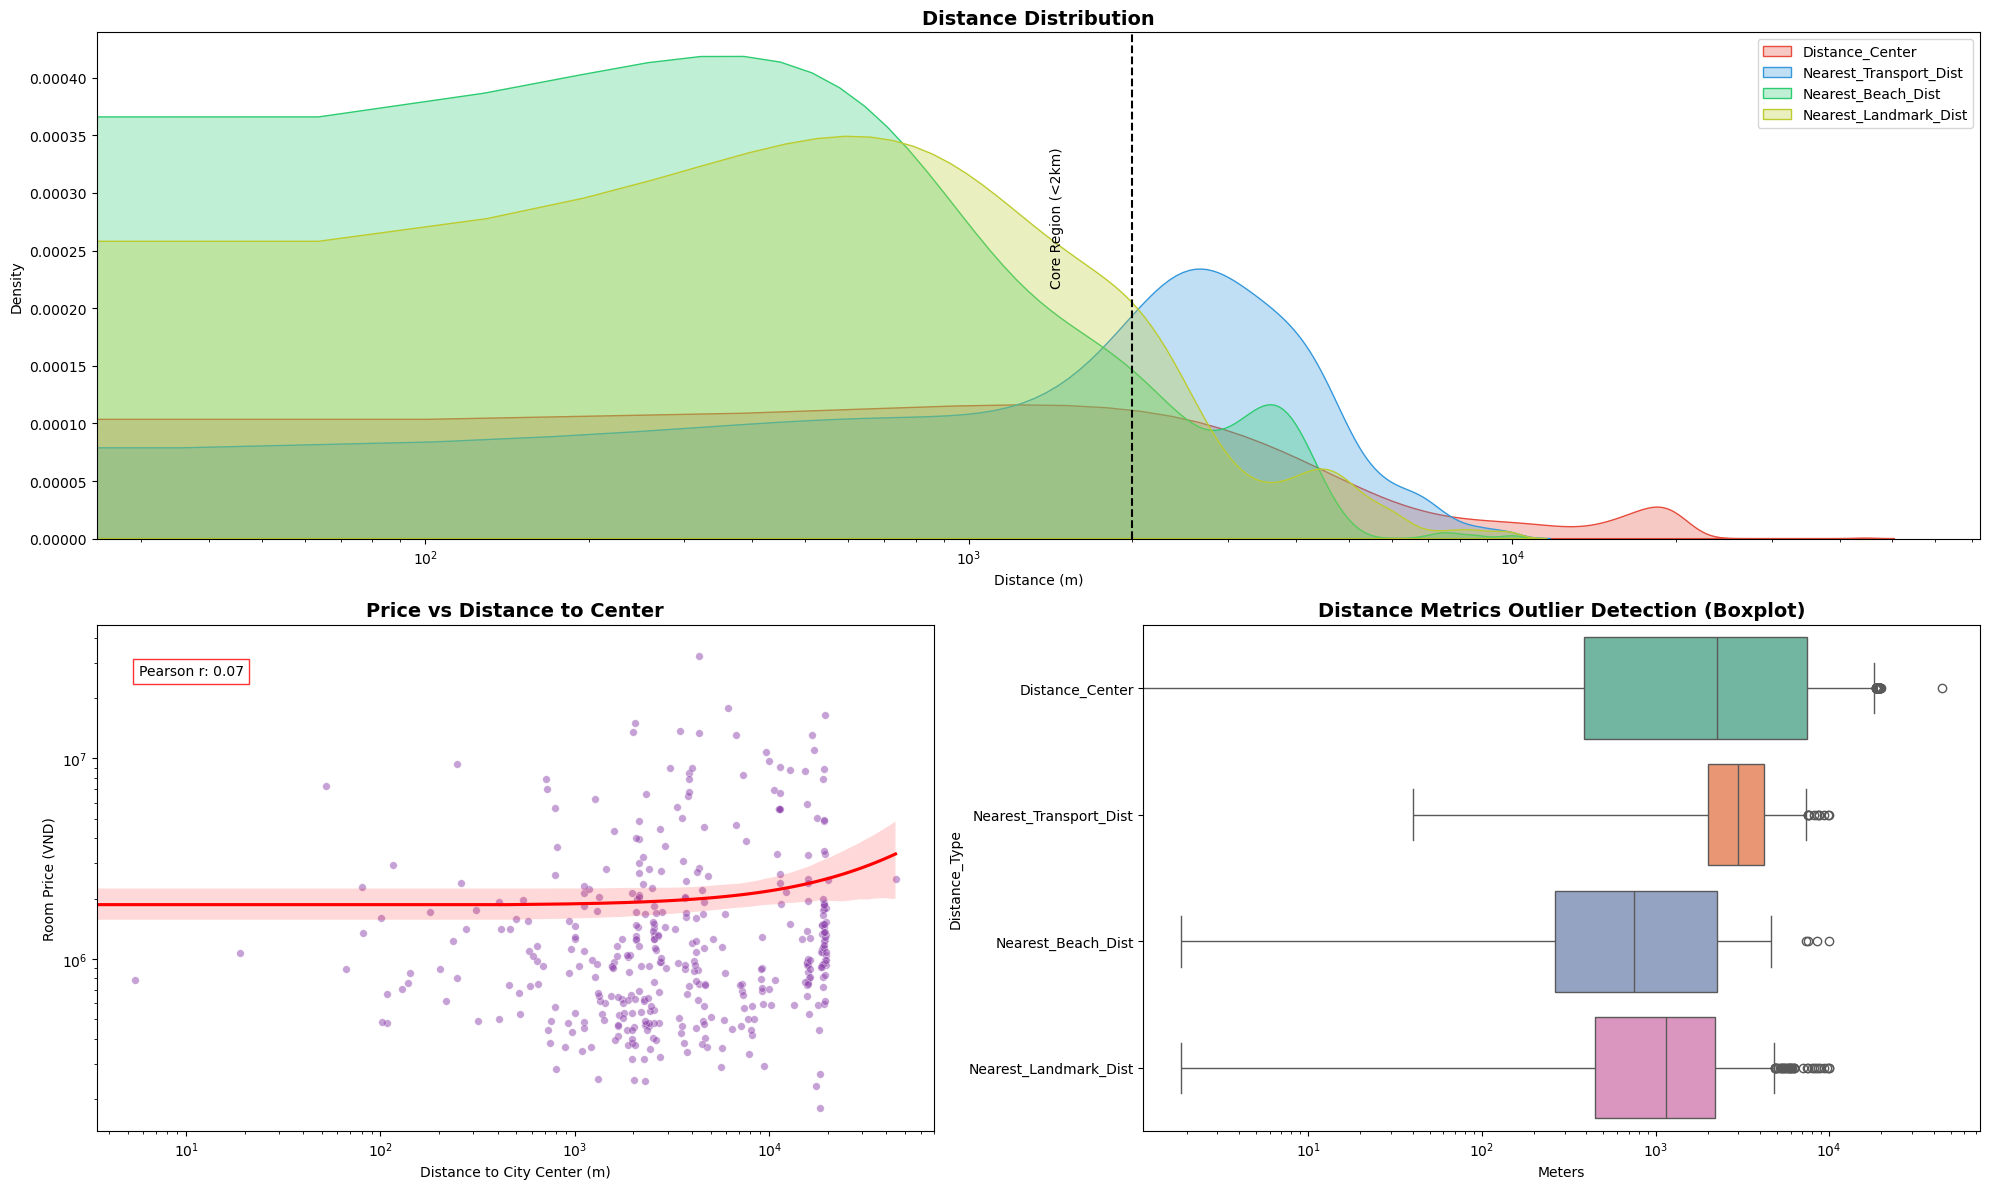

 Distance_Center: Median = 2248m, Max = 44630m
 Nearest_Transport_Dist: Median = 2984m, Max = 9997m
 Nearest_Beach_Dist: Median = 755m, Max = 9987m
 Nearest_Landmark_Dist: Median = 1147m, Max = 9983m
Pearson correlation (Distance_Center vs Price_Display): r = 0.07


In [19]:
analyze_location_accessibility(df_hotels)

Kết quả phân tích không gian cho thấy sự tập trung rõ rệt của các cơ sở lưu trú tại các điểm nóng du lịch, đặc biệt là khu vực ven biển. Về khả năng tiếp cận bãi biển, giá trị trung vị chỉ 755 mét, cho thấy phần lớn khách sạn nằm rất gần bờ biển, với đỉnh phân phối KDE tập trung ở khoảng <1 km, nhấn mạnh định hướng "du lịch biển" là trọng tâm của thị trường.

Khả năng tiếp cận trung tâm thành phố có giá trị trung vị khoảng 2,248 mét, phản ánh xu hướng các khách sạn nằm tại vùng ven trung tâm hoặc các khu phát triển mới ven biển, thay vì tập trung dày đặc trong lõi đô thị cũ. Khoảng cách trung vị đến danh lam thắng cảnh/địa danh gần nhất là 1,147m, thấp hơn đáng kể so với khoảng cách đến trung tâm thành phố (2,248m). Dữ liệu này chỉ ra rằng các khách sạn có xu hướng co cụm xung quanh các điểm hút khách du lịch để tối ưu hóa trải nghiệm thuận tiện cho khách lưu trú. Về tiếp cận giao thông công cộng, khoảng cách trung vị đến trạm giao thông gần nhất là $\approx$3 km, cho thấy hạ tầng giao thông công cộng chưa phải là yếu tố quyết định vị trí khách sạn, phù hợp với thực tế khách du lịch thường sử dụng dịch vụ taxi hoặc Grab.

Phân tích mối quan hệ giữa vị trí và giá phòng đem lại kết quả bất ngờ. Hệ số tương quan Pearson giữa Distance_Center và Price_Display là $r = 0.07$, chỉ ra mối tương quan thuận chiều rất yếu. Xu hướng hồi quy trên biểu đồ Log-Log cho thấy giá có phần nhích lên với khoảng cách tăng. Nguyên nhân được lý giải bởi sự hiện diện của các resort cao cấp nằm xa trung tâm nhưng chiếm vị trí ven biển biệt lập, với mức giá phòng rất cao, làm đảo lộn quy luật giá thông thường.

Từ đó ta có thể kết luận biến `Distance_Center` đơn lẻ không phải là chỉ báo đáng tin cậy để dự đoán giá phòng. Để mô hình định giá phản ánh chính xác, cần kết hợp biến này với loại hình bất động sản, chẳng hạn tạo biến tương tác `Distance * Is_Resort`, nhằm nắm bắt thực tế: "Xa trung tâm là rẻ nếu là nhà nghỉ, nhưng đắt nếu là resort cao cấp".

**Analysis of Categorical Columns**

**Nhóm đặc Địa lý & Phân bố `City, Area`**


CITY
Unique Values: 3
Missing Values: 0 (0.00%)
Most Frequent: 'Da Nang' (179 occurrences)

AREA
Unique Values: 35
Missing Values: 0 (0.00%)
Most Frequent: 'Phước Mỹ' (87 occurrences)

NEAREST_BEACH_NAME
Unique Values: 13
Missing Values: 150 (30.24%)
Most Frequent: 'Long Beach' (100 occurrences)

NEAREST_LANDMARK_NAME
Unique Values: 26
Missing Values: 5 (1.01%)
Most Frequent: 'My Khe Beach' (106 occurrences)


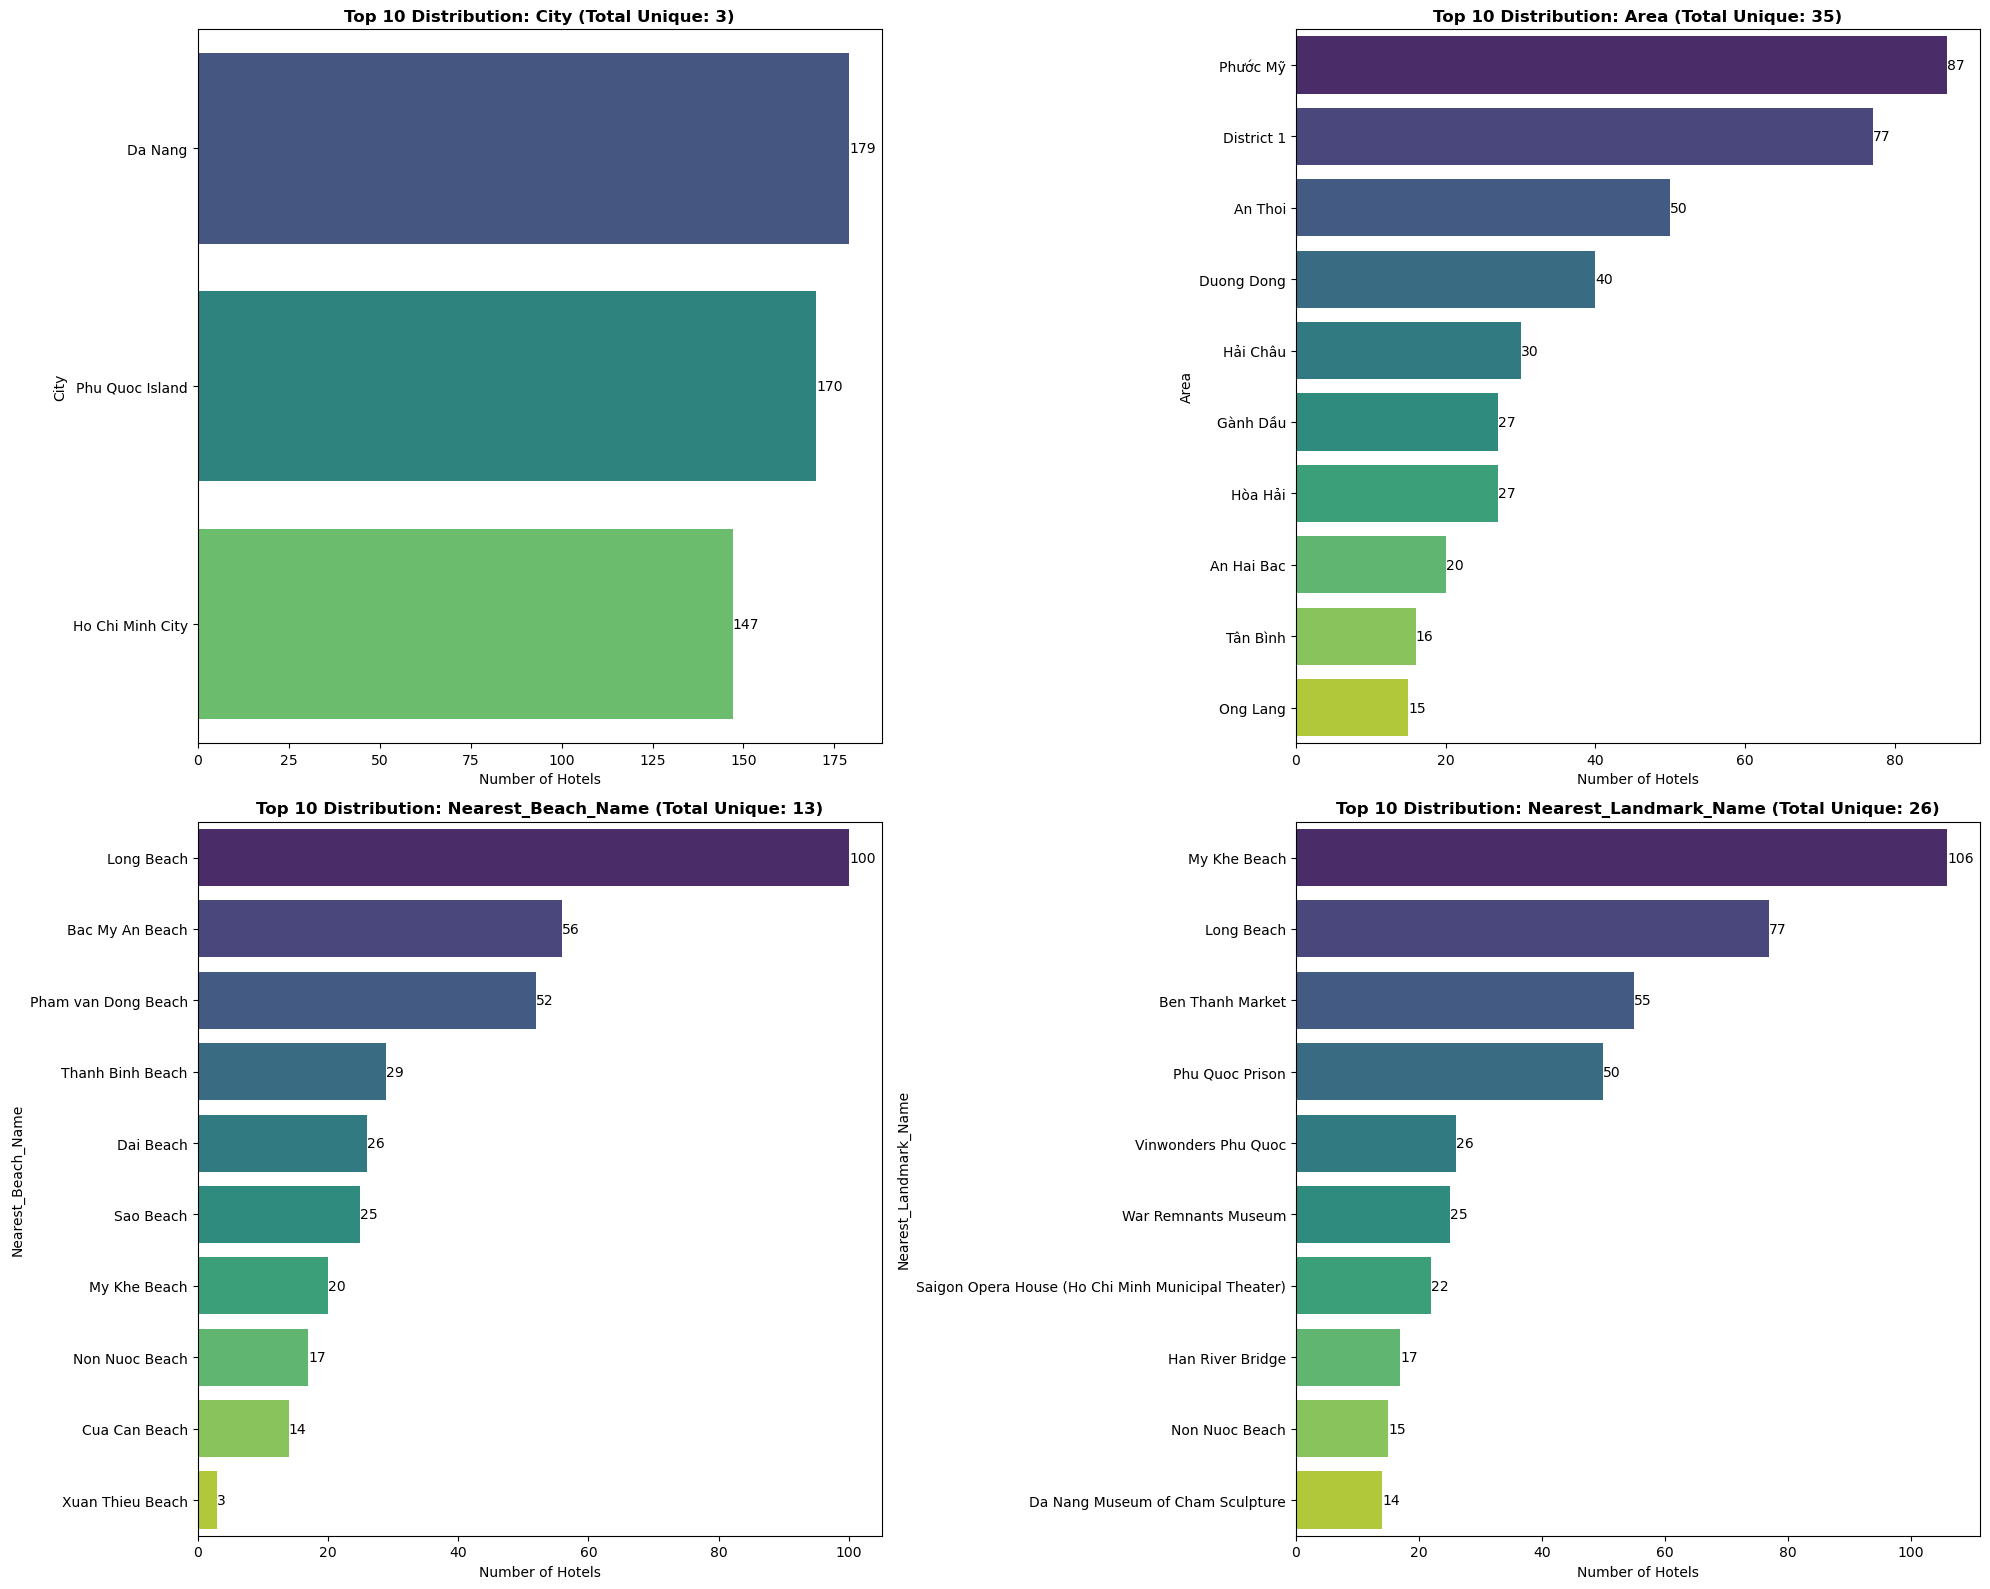

In [20]:
analyze_categorical_data(df_hotels)

Kết quả khảo sát dữ liệu địa lý cho thấy sự phân bổ tương đối đồng đều của các cơ sở lưu trú tại ba thành phố du lịch trọng điểm của Việt Nam. Trong đó, Đà Nẵng chiếm tỷ trọng lớn nhất với 179 khách sạn, đóng vai trò thị trường đại diện chính; Phú Quốc và TP.HCM lần lượt có 170 và 147 khách sạn. Sự chênh lệch tương đối nhỏ giữa ba thành phố (Range gần 30 đơn vị) đảm bảo rằng các mô hình học máy xây dựng trên dữ liệu này sẽ không bị thiên lệch quá mức về đặc điểm của một địa phương cụ thể.

Ở cấp độ vi mô, dữ liệu cho thấy sự hình thành rõ rệt các điểm nóng phân bố. Tại Đà Nẵng, khu vực Phước Mỹ là điểm tập trung lớn nhất với 87 khách sạn, nhấn mạnh xu hướng "bám biển" của thị trường; TP.HCM tập trung cao độ tại Quận 1 với 77 khách sạn, phản ánh đặc thù du lịch đô thị hướng tâm; Phú Quốc tập trung chủ yếu tại An Thới (50 khách sạn) và Dương Đông (40 khách sạn).

Phân tích các điểm mốc tham chiếu cho thấy vai trò quan trọng của vị trí đối với giá trị bất động sản. Bãi biển Mỹ Khê được nhắc đến nhiều nhất trong biến Landmark (106 lần), và Bãi Dài (Long Beach) đứng đầu biến Beach (100 lần), minh chứng cho việc các khách sạn lựa chọn vị trí gần các bãi biển nổi tiếng nhằm tối ưu hóa khả năng thu hút khách. Tuy nhiên, biến Nearest_Beach_Name có tỷ lệ thiếu dữ liệu cao (30.24%), chủ yếu do các khách sạn tại TP.HCM không giáp biển. Để mô hình định giá phản ánh chính xác, cần xử lý bằng cách gán nhãn riêng ("No Beach") hoặc sử dụng khoảng cách giả định cực đại thay vì điền giá trị trung bình, tránh sai lệch dữ liệu.

Tổng kết, cấu trúc dữ liệu địa lý đạt độ cân bằng tốt ở cấp độ thành phố nhưng thể hiện tính co cụm mạnh ở cấp quận/huyện. Chiến lược định giá cần xem xét yếu tố "Quận/Huyện" như một biến số quan trọng, bởi giá đất và nhu cầu tại các khu vực trọng điểm như Quận 1 (TP.HCM) hay Phước Mỹ (Đà Nẵng) khác biệt rõ rệt so với các vùng lân cận, ảnh hưởng trực tiếp đến mức giá phòng.

### **2. Room Pricing & Features**

#### **2.1 Load Raw Data**

Trong giai đoạn đầu của quá trình khám phá dữ liệu khách sạn về cơ cấu giá và đặc điểm phòng, chúng em tiến hành tải dữ liệu thô (raw data) từ tệp CSV đã thu thập được trong thư mục `data/raw`.

In [21]:
rooms_path = "../data/raw/rooms_list.csv"
df_rooms = pd.read_csv(rooms_path)

#### **2.2 Basic Information**

Dữ liệu được đọc từ tệp `rooms_list.csv` và được lưu vào biến `df_rooms`. Để có cái nhìn ban đầu về cấu trúc và đặc điểm của dataset, chúng em hiển thị 5 dòng đầu tiên và 5 dòng cuối cùng.

In [22]:
# Xem 5 dòng đầu
df_rooms.head()

,hotel_id,check_in_date,room_id,room_name,room_size,max_occupancy,max_extrabeds,num_bedrooms,total_bed_count,bed_configuration,...,RoomFac_Wi-Fi [free],RoomFac_Window,RoomFac_Window that opens,RoomFac_Wine glasses,RoomFac_Wooden/parqueted flooring,RoomFac_Yoga mat (rental),RoomFac_iPod docking station,RoomFac_Board games,RoomFac_Blu-ray player,RoomFac_Tatami flooring
0,38099260,2026-03-30,628323174,Apartment,Room size: 100 m²/1076 ft²,6,0,2,3,"2 x 2 single beds, 1 x 1 queen bed",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76682756,2026-02-27,1186143023,Private Villa,NaN,16,0,1,8,8 x 8 queen beds,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4655979,2026-05-13,31888715,Apartment,Room size: 82 m²/883 ft²,4,0,2,2,"1 x 1 king bed, 1 x 1 king bed",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5239417,2026-04-23,45812867,Apartment,Room size: 66 m²/710 ft²,6,0,2,2,"1 x 1 king bed, 1 x 1 king bed",...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,47135281,2026-02-08,1242583980,Superior Studio,Room size: 38 m²/409 ft²,2,0,1,1,1 x 1 queen bed,...,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [23]:
# Xem 5 dòng cuối
df_rooms.tail()

,hotel_id,check_in_date,room_id,room_name,room_size,max_occupancy,max_extrabeds,num_bedrooms,total_bed_count,bed_configuration,...,RoomFac_Wi-Fi [free],RoomFac_Window,RoomFac_Window that opens,RoomFac_Wine glasses,RoomFac_Wooden/parqueted flooring,RoomFac_Yoga mat (rental),RoomFac_iPod docking station,RoomFac_Board games,RoomFac_Blu-ray player,RoomFac_Tatami flooring
27226,6993254,2026-02-07,85383918,Suite with Bathtub,Room size: 27 m²/291 ft²,2,0,1,1,1 x 1 queen bed,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
27227,49501856,2026-04-17,778469240,Ground Floor Room,Room size: 20 m²/215 ft²,2,0,1,1,1 x 1 king bed,...,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
27228,49501856,2026-04-17,778469389,Superior Double City View,Room size: 28 m²/301 ft²,2,0,1,1,1 x 1 king bed,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
27229,49501856,2026-04-17,778483901,Loft King Room,Room size: 45 m²/484 ft²,2,0,1,1,1 x 1 king bed,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
27230,49501856,2026-04-17,778475914,One Bedroom Suite with Bathtub,Room size: 50 m²/538 ft²,2,0,1,1,1 x 1 king bed,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


**Tính số dòng, số cột của dữ liệu**

In [24]:
num_rows_df_rooms, num_cols_df_rooms = df_rooms.shape
print(f"Number of rows: {num_rows_df_rooms}")
print(f"Number of columns: {num_cols_df_rooms}")

Number of rows: 27231
Number of columns: 206


Bộ dữ liệu phòng khách sạn thu thập được bao gồm 27.231 dòng và 206 thuộc tính, phản ánh một hệ thống mô tả phong phú và đa chiều về đặc điểm phòng, cấu hình giường, giá niêm yết, đánh giá chất lượng cũng như các tiện nghi chi tiết ở cấp độ từng phòng. Tổng thể, cấu trúc dữ liệu với số lượng thuộc tính lớn và mức độ chi tiết cao cho phép tiến hành các phân tích nâng cao như phân cụm phòng theo cấu hình tiện nghi, mô hình hoá giá dựa trên thuộc tính, hoặc đánh giá mối liên hệ giữa chất lượng tiện nghi và điểm đánh giá của khách hàng.

#### **2.3 Data Integrity**

**Checking duplicated data**

Để đảm bảo tính toàn vẹn của tập dữ liệu, chúng em đã tiến hành kiểm tra toàn diện các bản ghi trùng lặp trên tất cả các thuộc tính bằng phương pháp `duplicated` trong Pandas với tham số `keep = False`. Phương pháp này giúp xác định bất kỳ hàng nào hoàn toàn giống nhau về tất cả các đặc trưng.

In [25]:
duplicated_full = df_rooms.duplicated(keep = False)
print(duplicated_full.any())

False


Kết quả kiểm tra cho thấy không có bản ghi nào bị trùng lặp trong tập dữ liệu. Kết quả này xác nhận rằng mỗi phòng của một khách sạn tại một ngày nhận phòng nhất định được đại diện duy nhất trong dữ liệu, đảm bảo độ tin cậy cho các phân tích tiếp theo ở cấp độ phòng.

**Percentage of missing values**

Để đánh giá chất lượng dữ liệu ta tiến hành kiểm tra tỷ lệ giá trị thiếu trong toàn bộ các cột của tập dữ liệu `df_rooms`

In [26]:
num_rows = df_rooms.shape[0]

for col_name in df_rooms.columns:
    if df_rooms[col_name].dtype == object:
        missing_count = df_rooms[col_name].isna().sum() + (df_rooms[col_name] == "").sum()
    else:
        missing_count = df_rooms[col_name].isna().sum()
    missing_percent = (missing_count / num_rows) * 100
    print(f"{col_name:40}: {missing_percent:.2f}%")

hotel_id                                : 0.00%
check_in_date                           : 0.00%
room_id                                 : 0.00%
room_name                               : 0.00%
room_size                               : 2.19%
max_occupancy                           : 0.00%
max_extrabeds                           : 0.00%
num_bedrooms                            : 0.00%
total_bed_count                         : 0.00%
bed_configuration                       : 2.28%
base_price                              : 0.00%
review_score                            : 0.00%
star_rating                             : 0.00%
Dist_airport_km                         : 3.50%
Dist_transportation_km                  : 12.89%
Dist_hospitals_km                       : 1.21%
Dist_shopping_km                        : 19.14%
Dist_convenienceStore_km                : 19.34%
Dist_atm_km                             : 43.29%
RoomFac_Accessible by elevator          : 46.48%
RoomFac_Accessible by stairs       

Kết quả cho thấy các cột định danh và thông tin cơ bản của phòng như `hotel_id`, `check_in_date`, `room_id`, `room_name`, `max_occupancy`, `max_extrabeds`, `num_bedrooms`, `total_bed_count`, `base_price`, `review_score` và `star_rating` không có giá trị thiếu (0.00%), đảm bảo tính đầy đủ và nhất quán của thông tin định danh và dữ liệu cốt lõi.

Ngược lại, một số cột liên quan đến đặc điểm vật lý hoặc tiện nghi của phòng có tỷ lệ giá trị thiếu cao. Ví dụ, các cột `RoomFac_Accessible toilet` và `RoomFac_Accessible vanities` có tới hơn 90% giá trị thiếu, trong khi `RoomFac_Activity Kits` và `RoomFac_Board games` gần như hoàn toàn thiếu dữ liệu (99.66%–99.98%). Một số tiện nghi phổ biến hơn như `RoomFac_Air conditioning` hay `RoomFac_Hair dryer` chỉ thiếu dưới 5%, phản ánh rằng các tiện nghi này hầu hết được cung cấp và ghi nhận đầy đủ.

Tỷ lệ giá trị thiếu cũng dao động đáng kể ở các cột liên quan đến vị trí và tiện ích xung quanh khách sạn. Các cột `Dist_airport_km`, `Dist_transportation_km`, `Dist_shopping_km`, `Dist_convenienceStore_km` và `Dist_atm_km` có giá trị thiếu từ 3.50% đến 43.29%.

Nhìn chung, tập dữ liệu `df_rooms` cung cấp đầy đủ thông tin cơ bản về phòng và khách sạn, trong khi các cột về tiện nghi đặc biệt hoặc dịch vụ tùy chọn có nhiều giá trị thiếu.

#### **2.4 Data Semantics**

**The meaning of each row**

Mỗi dòng trong bộ dữ liệu đại diện cho một phiên bản đặc tả đầy đủ của một phòng khách sạn tại một thời điểm lưu trú cụ thể. Cấu trúc này kết hợp đồng thời thông tin định danh phòng (`hotel_id`, `room_id`, `room_name`), đặc tính vật lý (`room_size`, `num_bedrooms`, `bed_configuration`), khả năng phục vụ (`max_occupancy`, `max_extrabeds`), dữ liệu chất lượng (`review_score`, `star_rating`), vị trí tương đối (`distance-to-amenities`), và hơn 180 tiện nghi phòng được mã hoá nhị phân. Như vậy, mỗi dòng phản ánh một “snapshot” hoàn chỉnh của phòng — bao gồm giá, cấu hình, và toàn bộ tiện ích — tại thời điểm `check_in_date`, tạo cơ sở chi tiết và giàu thông tin cho phân tích hành vi giá, phân loại phòng hoặc mô hình dự đoán chất lượng lưu trú.

**The meaning of each column**

In [27]:
df_rooms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27231 entries, 0 to 27230
Columns: 206 entries, hotel_id to RoomFac_Tatami flooring
dtypes: float64(196), int64(6), object(4)
memory usage: 42.8+ MB


In [28]:
for i, col in enumerate(df_rooms.columns, start = 1):
    print(f"{i:03d}. {col}")

001. hotel_id
002. check_in_date
003. room_id
004. room_name
005. room_size
006. max_occupancy
007. max_extrabeds
008. num_bedrooms
009. total_bed_count
010. bed_configuration
011. base_price
012. review_score
013. star_rating
014. Dist_airport_km
015. Dist_transportation_km
016. Dist_hospitals_km
017. Dist_shopping_km
018. Dist_convenienceStore_km
019. Dist_atm_km
020. RoomFac_Accessible by elevator
021. RoomFac_Accessible by stairs
022. RoomFac_Accessible toilet
023. RoomFac_Accessible vanities
024. RoomFac_Activity Kits
025. RoomFac_Adapted bath
026. RoomFac_Adapter
027. RoomFac_Additional bathroom
028. RoomFac_Additional toilet
029. RoomFac_Adjustable height hand-held shower wand
030. RoomFac_Air conditioning
031. RoomFac_Air purifier
032. RoomFac_Alarm clock
033. RoomFac_Alarm clock telephone ringer
034. RoomFac_Alcohol
035. RoomFac_Audible alarm
036. RoomFac_BBQ facilities
037. RoomFac_Baby amenities (upon request)
038. RoomFac_Baby cot (upon request)
039. RoomFac_Baby safety gat

Mỗi cột trong bộ dữ liệu thể hiện một nhóm thông tin cấu trúc hoặc chức năng mô tả đặc điểm của phòng khách sạn tại thời điểm quan sát.

Các cột định danh như `hotel_id`, `room_id`, `room_name`, và `check_in_date` cung cấp thông tin nhận diện và ngữ cảnh thời gian của từng phòng.

Nhóm thuộc tính mô tả đặc trưng vật lý và sức chứa bao gồm `room_size`, `num_bedrooms`, `total_bed_count`, `bed_configuration`, `max_occupancy` và `max_extrabeds`. Các biến này mô tả kích thước, số lượng phòng ngủ, tổng số giường trong một phòng, loại giường và khả năng chứa tối đa của từng phòng. Chúng đóng vai trò quan trọng trong việc mô phỏng sự tiện lợi, sự phù hợp của phòng đối với các phân khúc khách hàng khác nhau.

Các thuộc tính kinh tế và chất lượng trải nghiệm, bao gồm `base_price`, `review_score` và `star_rating`, phản ánh giá trị thị trường (giá niêm yết cơ bản của phòng) và đánh giá chủ quan của khách hàng. `review_score` thể hiện điểm đánh giá trung bình của khách hàng dành cho khách sạn hoặc phòng, nằm trong thang từ 0 đến 10. Biến này phản ánh trải nghiệm thực tế từ người dùng và có ảnh hưởng mạnh đến khả năng đặt phòng, mức giá và doanh thu. `star_rating` mô tả xếp hạng sao chính thức của khách sạn, dựa trên các tiêu chuẩn cơ sở vật chất và dịch vụ, nằm trong thang từ 1 sao (Cơ bản) đến 5 sao (Sang trọng).

Một nhóm thuộc tính quan trọng khác là các biến định vị không gian, như `Dist_airport_km`, `Dist_transportation_km`, `Dist_hospitals_km` hoặc `Dist_shopping_km`, và các địa điểm quan tâm khác (points of interest). Các biến này mô tả khoảng cách từ khách sạn đến các tiện ích đô thị và cơ sở hạ tầng quan trọng.

Đáng chú ý nhất là nhóm hơn 180 thuộc tính bắt đầu bằng tiền tố `RoomFac_` — đây là hệ thống mã hóa nhị phân biểu thị sự hiện diện của từng tiện nghi trong phòng, bao gồm nhiều nhóm tiện nghi.

Nhóm đầu tiên tập trung vào các đặc điểm hỗ trợ tiếp cận (ví dụ: `RoomFac_Accessible by elevator`, `Accessible toilet`, `Braille and tactile signage`, `Hearing accessible kit`, `Roll-in shower`, `Lowered view port in door`). Những thuộc tính này mô tả khả năng tiếp cận của phòng đối với người khuyết tật hoặc người có hạn chế vận động/ thị lực/ thính lực, qua đó cho phép các phân tích liên quan đến tính công bằng trong thiết kế (accessibility equity), khả năng phục vụ đa dạng người dùng, và mức độ tuân thủ tiêu chuẩn quốc tế về tiếp cận trong lưu trú.

Một nhóm lớn khác mô tả tiện nghi lưu trú và trang thiết bị tiêu chuẩn như `Air conditioning`, `Heating`, `Wi-Fi (free/charges apply)`, `Refrigerator`, `Coffee/tea maker`, `Hair dryer`, `TV [flat screen]`, `Desk`, `Ironing facilities`, và `Towels`. Đây là các yếu tố nền tảng góp phần xác định sự thoải mái trong lưu trú và thường là nhân tố chủ đạo trong mô hình dự báo hài lòng hoặc phân khúc phòng theo tiêu chuẩn cơ bản.

Nhóm tiện nghi cao cấp và đặc thù trải nghiệm bao gồm `Private pool`, `Open air bath privileges`, `Hot spring access`, `Executive lounge access`, `Complimentary spa access`, `Full kitchen`, `In-room meal prep`, `Laptop workspace`, và `Espresso machine with pods`. Những biến này phản ánh sự khác biệt về mức độ sang trọng và cấu hình dịch vụ, cho phép mô hình hóa chiến lược định vị sản phẩm hoặc đo lường tác động của tiện ích cao cấp lên hành vi đặt phòng.

Bên cạnh đó là nhóm tiện nghi giải trí – gia đình – trẻ em, như `Board games`, `Books/DVDs/music for children`, `Baby cot`, `High chair`, `Video game console`, `Streaming services`, và `Outdoor furniture`. Các thuộc tính này giúp nghiên cứu hành vi của các nhóm khách hàng đặc thù, chẳng hạn gia đình hoặc khách lưu trú dài hạn, vốn có yêu cầu tiện nghi khác biệt so với khách du lịch thông thường.

Cuối cùng, các thuộc tính liên quan đến an toàn và sức khỏe như `Smoke detector`, `Fire extinguisher`, `First aid kit`, `Hand sanitizer`, `Carbon monoxide detector`, `Trash cans`, và `Hypoallergenic` cung cấp thông tin quan trọng về tiêu chuẩn an toàn – vệ sinh của phòng. Đây là nhóm biến đặc biệt hữu ích trong các nghiên cứu sau đại dịch COVID-19, khi tiêu chuẩn vệ sinh trở thành yếu tố quan trọng trong quyết định đặt phòng.

**Column Data Types and Compatibility for Analysis**

In [29]:
for col in df_rooms.columns:
    col_type = df_rooms[col].dtype
    print(f"{col:25} Type: {col_type}")

hotel_id                  Type: int64
check_in_date             Type: object
room_id                   Type: int64
room_name                 Type: object
room_size                 Type: object
max_occupancy             Type: int64
max_extrabeds             Type: int64
num_bedrooms              Type: int64
total_bed_count           Type: int64
bed_configuration         Type: object
base_price                Type: float64
review_score              Type: float64
star_rating               Type: float64
Dist_airport_km           Type: float64
Dist_transportation_km    Type: float64
Dist_hospitals_km         Type: float64
Dist_shopping_km          Type: float64
Dist_convenienceStore_km  Type: float64
Dist_atm_km               Type: float64
RoomFac_Accessible by elevator Type: float64
RoomFac_Accessible by stairs Type: float64
RoomFac_Accessible toilet Type: float64
RoomFac_Accessible vanities Type: float64
RoomFac_Activity Kits     Type: float64
RoomFac_Adapted bath      Type: float64
RoomFa

Kết quả phân tích kiểu dữ liệu của từng cột trong tập dữ liệu cho thấy các trường nhận dạng và định danh như `hotel_id`, `room_id`, `max_occupancy`, `max_extrabeds`, `num_bedrooms` và `total_bed_count` đều có kiểu số nguyên (`int64`), phù hợp với bản chất định lượng của chúng. Các cột `base_price`, `review_score`, `star_rating` và các khoảng cách tới các địa điểm xung quanh khách sạn (`Dist_airport_km`, `Dist_transportation_km`, `Dist_hospitals_km`, `Dist_shopping_km`, `Dist_convenienceStore_km`, `Dist_atm_km`) được lưu dưới dạng số thực (`float64`), thích hợp cho các phân tích thống kê, tính toán và mô hình hóa.

Các cột mô tả thông tin văn bản như `check_in_date`, `room_name`, `room_size`, `bed_configuration` vẫn ở kiểu `object` do dữ liệu gốc là chuỗi hoặc định dạng hỗn hợp. Trong trường hợp cần phân tích sâu hơn (ví dụ trích xuất ngày tháng từ `check_in_date` hay chuẩn hóa kích thước phòng từ `room_size`), cần thực hiện chuyển đổi kiểu dữ liệu sang `datetime` hoặc số tương ứng.

Đáng chú ý, hầu hết các cột tiện ích phòng (`RoomFac_*`) hiện đều có kiểu số thực (`float64`), trong đó các giá trị biểu diễn việc có hay không có tiện nghi (thường 0 hoặc 1) và giá trị `NaN` cho các thông tin thiếu. Việc lưu các cột này dưới dạng số thực thuận tiện cho các phân tích thống kê và mô hình học máy, tuy nhiên cần kiểm tra và xử lý giá trị thiếu trước khi sử dụng trong mô hình.

Nhìn chung, kiểu dữ liệu hiện tại của các cột phần lớn phù hợp với các bước tiền xử lý và phân tích tiếp theo, chỉ cần thực hiện một số chuyển đổi định dạng cơ bản cho các cột văn bản hoặc ngày tháng để chuẩn hóa dữ liệu.

#### **2.5 Distribution & Visualization**

**Analysis of Numeric Columns**

**Đặc trưng `base_price`**

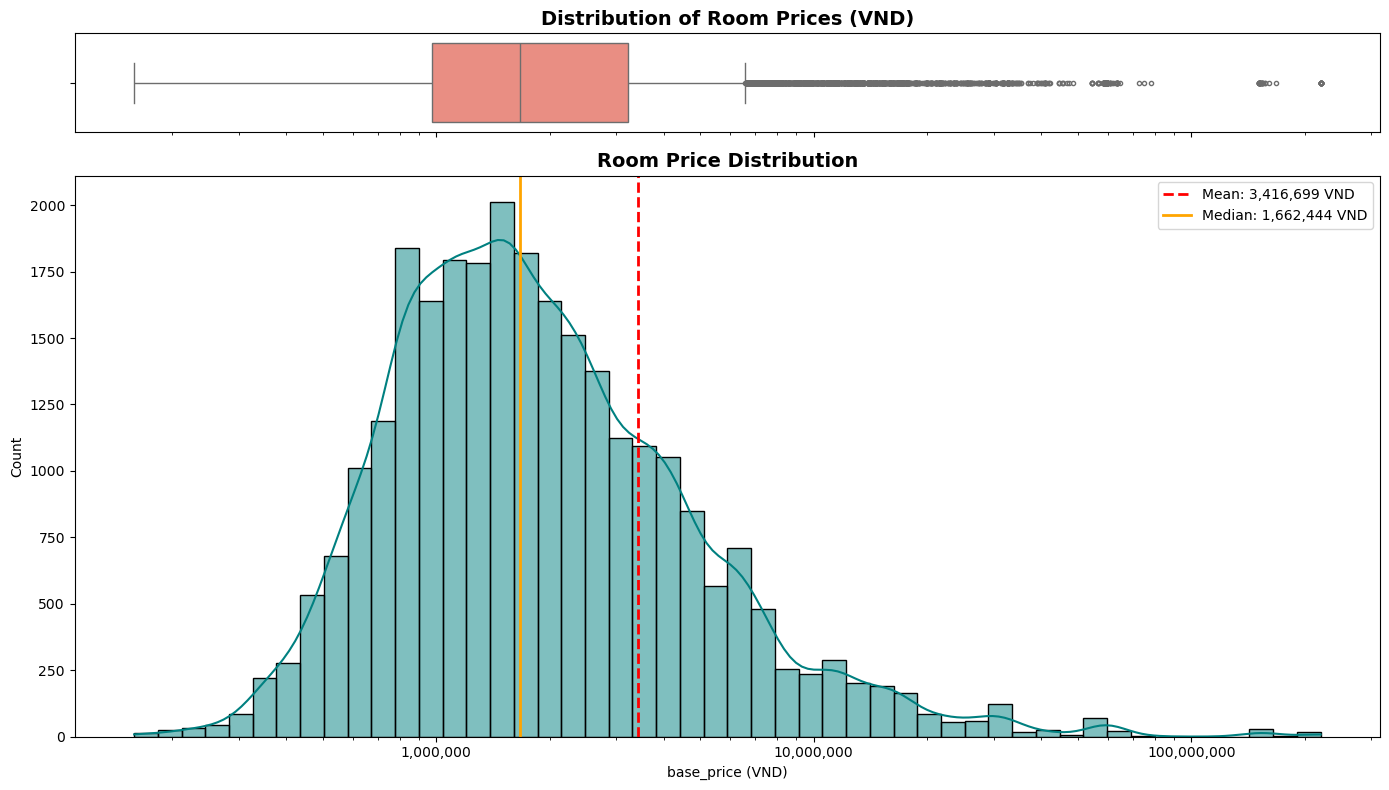

Max Value: 220,207,860 VND
Mean Value: 3,416,699 VND
Median Value: 1,662,444 VND
Q1 - Q3 Range: 976,356 -> 3,219,336 VND
IQR: 2,242,980 VND
Upper Bound (for outliers): 6,583,806 VND
Number of Outliers: 2453 (9.01%)


In [30]:
plot_price_distribution(df_rooms)

Phân tích thống kê mô tả trên biến `base_price` cho thấy phân bố giá phòng có độ lệch phải rõ rệt (highly right-skewed). Minh chứng là sự chênh lệch đáng kể giữa giá trị trung bình (Mean $\approx$ 129.479 VND) và giá trị trung vị (Median $\approx$ 63.000 VND). Giá trị trung bình cao gấp đôi trung vị cho thấy phân bố bị kéo dãn bởi một nhóm nhỏ các phòng có giá cao.

Biểu đồ histogram cho thấy dữ liệu có xu hướng tiệm cận với phân phối chuẩn. Phần lớn các quan sát tập trung trong khoảng giá thấp (10.000 – 250.000 VND), phản ánh đặc thù của tập dữ liệu, có thể bao gồm nhiều loại hình lưu trú bình dân như homestay, dorm hoặc các phòng tính theo giờ.

Biểu đồ boxplot xác nhận sự tồn tại của một lượng lớn giá trị ngoại lai. Cụ thể, 2.453 mẫu (chiếm 9,01% tổng dữ liệu) được xác định là ngoại lai dựa trên phương pháp IQR (Interquartile Range), với ngưỡng trên (Upper Bound) là 249.500 VND. Giá trị lớn nhất được ghi nhận là 8.345.000 VND. Khoảng cách lớn giữa ngưỡng trên và giá trị cực đại cho thấy các ngoại lai này không phải là lỗi dữ liệu mà phản ánh phân khúc khách sạn cao cấp/hạng sang (Luxury/Resort Segment), tồn tại trong tập dữ liệu chủ yếu là phòng bình dân.

Kết quả phân tích cho thấy biến `base_price` không tuân theo phân phối chuẩn. Việc sử dụng trực tiếp giá trị này trong các mô hình hồi quy tuyến tính (Linear Regression) có thể dẫn đến sai số lớn do tác động của các giá trị ngoại lai.

**Nhóm đặc trưng đánh giá `review_score`, `star_rating`**

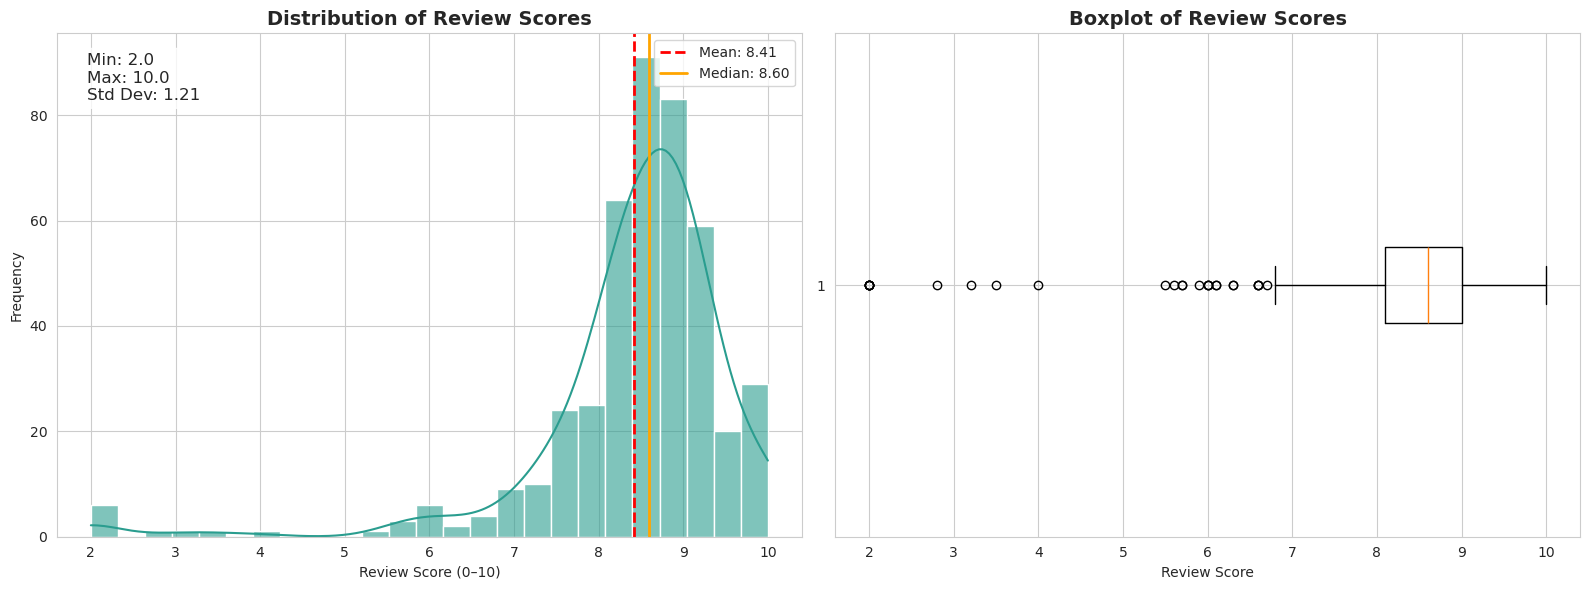

Central Tendency
   Mean     : 8.41
   Median   : 8.60

Dispersion And Range
   Min Value : 2.0
   Max Value : 10.0
   Std Dev   : 1.21


In [31]:
visualize_review_score(df_rooms)

Kết quả phân tích thống kê mô tả cho biến `review_score` cho thấy phân phối điểm đánh giá có xu hướng tập trung mạnh tại các mức điểm tích cực. Giá trị trung bình đạt 8.41, trong khi trung vị đạt 8.60 trên thang điểm 10. Mối quan hệ Median > Mean là minh chứng rõ ràng cho việc phân phối mang dạng lệch trái (negatively skewed distribution), hàm ý rằng phần lớn quan sát nằm ở vùng điểm cao và đuôi phân phối trải dài về phía điểm thấp.

Tuy vậy, độ lệch chuẩn tương đối lớn (SD = 1.21) cùng khoảng giá trị rộng (Min = 2.0, Max = 10.0) phản ánh sự tồn tại của mức độ biến thiên đáng kể trong chất lượng dịch vụ giữa các khách sạn.

Đáng chú ý, sự xuất hiện của nhóm điểm thấp dưới 7.0 — nằm ở đuôi trái của phân phối — có thể cho thấy sự hiện diện của các cơ sở có chất lượng thấp hoặc trường hợp khách hàng không hài lòng. Nhóm này, dù chiếm tỷ lệ nhỏ, đóng vai trò quan trọng trong việc đánh giá toàn diện mức độ đa dạng của trải nghiệm khách hàng và cần được xem xét trong các phân tích tiếp theo.

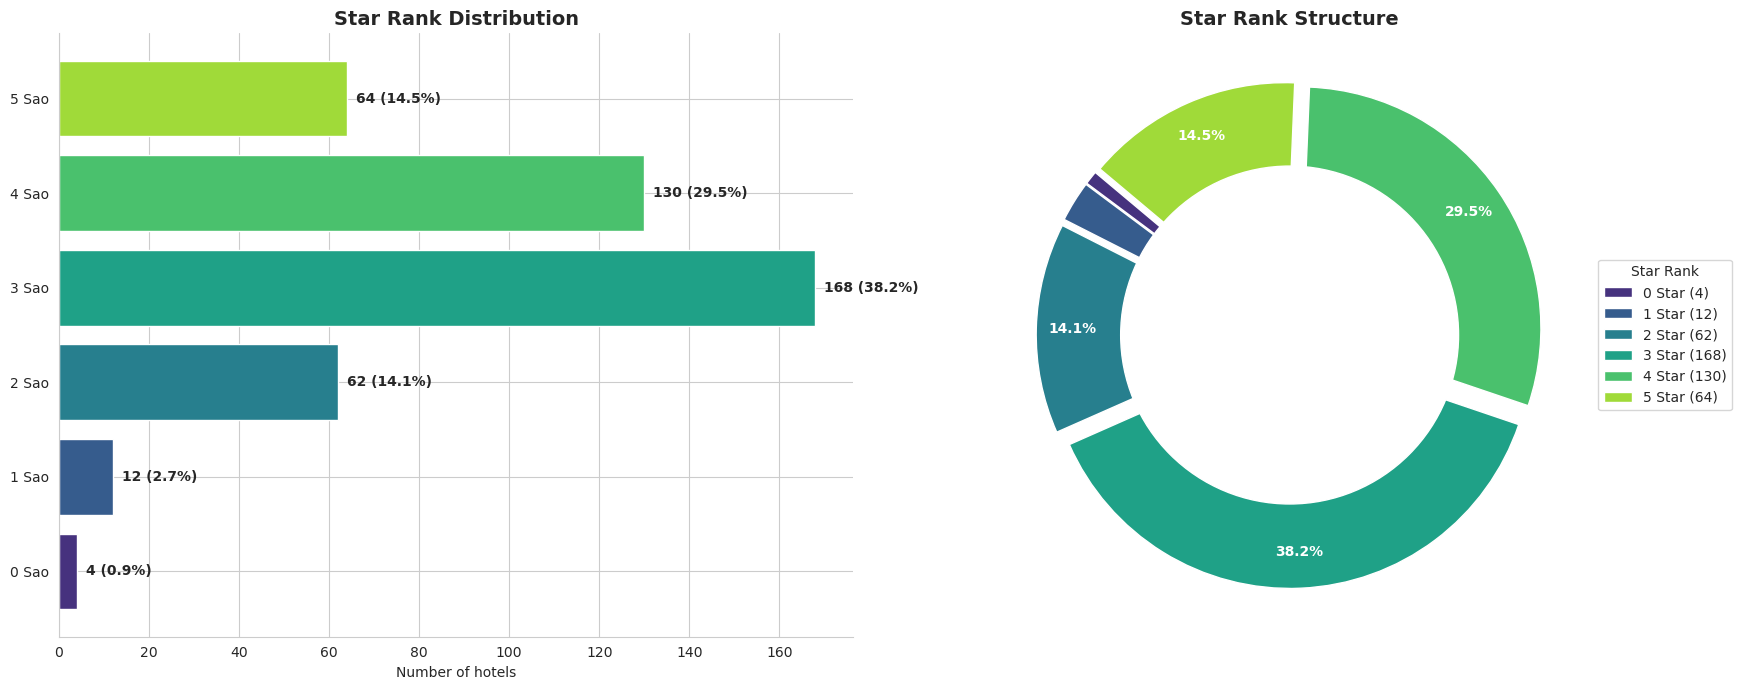

In [32]:
visualize_ratings(df_rooms)

Từ kết quả phân tích cho thấy cấu trúc thị trường có sự phân tầng rõ rệt, trong đó các khách sạn thuộc phân khúc Trung cấp (Mid-range) và Cận cao cấp (Upscale) giữ vai trò chủ đạo. Cụ thể, nhóm khách sạn 3 sao và 4 sao lần lượt chiếm 38,2% và 29,5% tổng số quan sát, hợp thành 67,7% toàn bộ thị phần. Tỷ trọng lớn và sự ổn định của hai phân khúc này phản ánh đây là cấu phần trung tâm của thị trường và tạo cơ sở quan trọng cho các phân tích tiếp theo liên quan đến hành vi giá, chất lượng dịch vụ và mô hình dự báo nhu cầu.

Ở phân khúc cao cấp, khách sạn 5 sao chiếm 14,5%, một tỷ lệ đủ đáng kể để tiến hành các phân tích chuyên sâu về đặc trưng giá và hành vi tiêu dùng của nhóm khách hàng cao cấp. Mặc dù có quy mô nhỏ hơn phân khúc trung cấp, nhóm 5 sao vẫn thể hiện vai trò độc lập khi xét đến cấu trúc giá, mức độ đa dạng tiện ích và hành vi đặt phòng.

Ngược lại, phân khúc bình dân (0–2 sao) chỉ chiếm khoảng 17,7% tổng dữ liệu, biểu thị sự mất cân bằng phân lớp (class imbalance) đáng chú ý. Sự lệch phân bố này dự báo rằng các mô hình học máy áp dụng sau này có thể đạt hiệu suất cao hơn ở nhóm khách sạn từ trung cấp trở lên, trong khi khả năng tổng quát hóa đối với phân khúc bình dân sẽ hạn chế hơn nếu không có biện pháp xử lý phù hợp.

**Nhóm đặc trưng vật lý `max_occupancy`, `max_extrabeds`, `num_bedrooms`, `total_bed_count`**

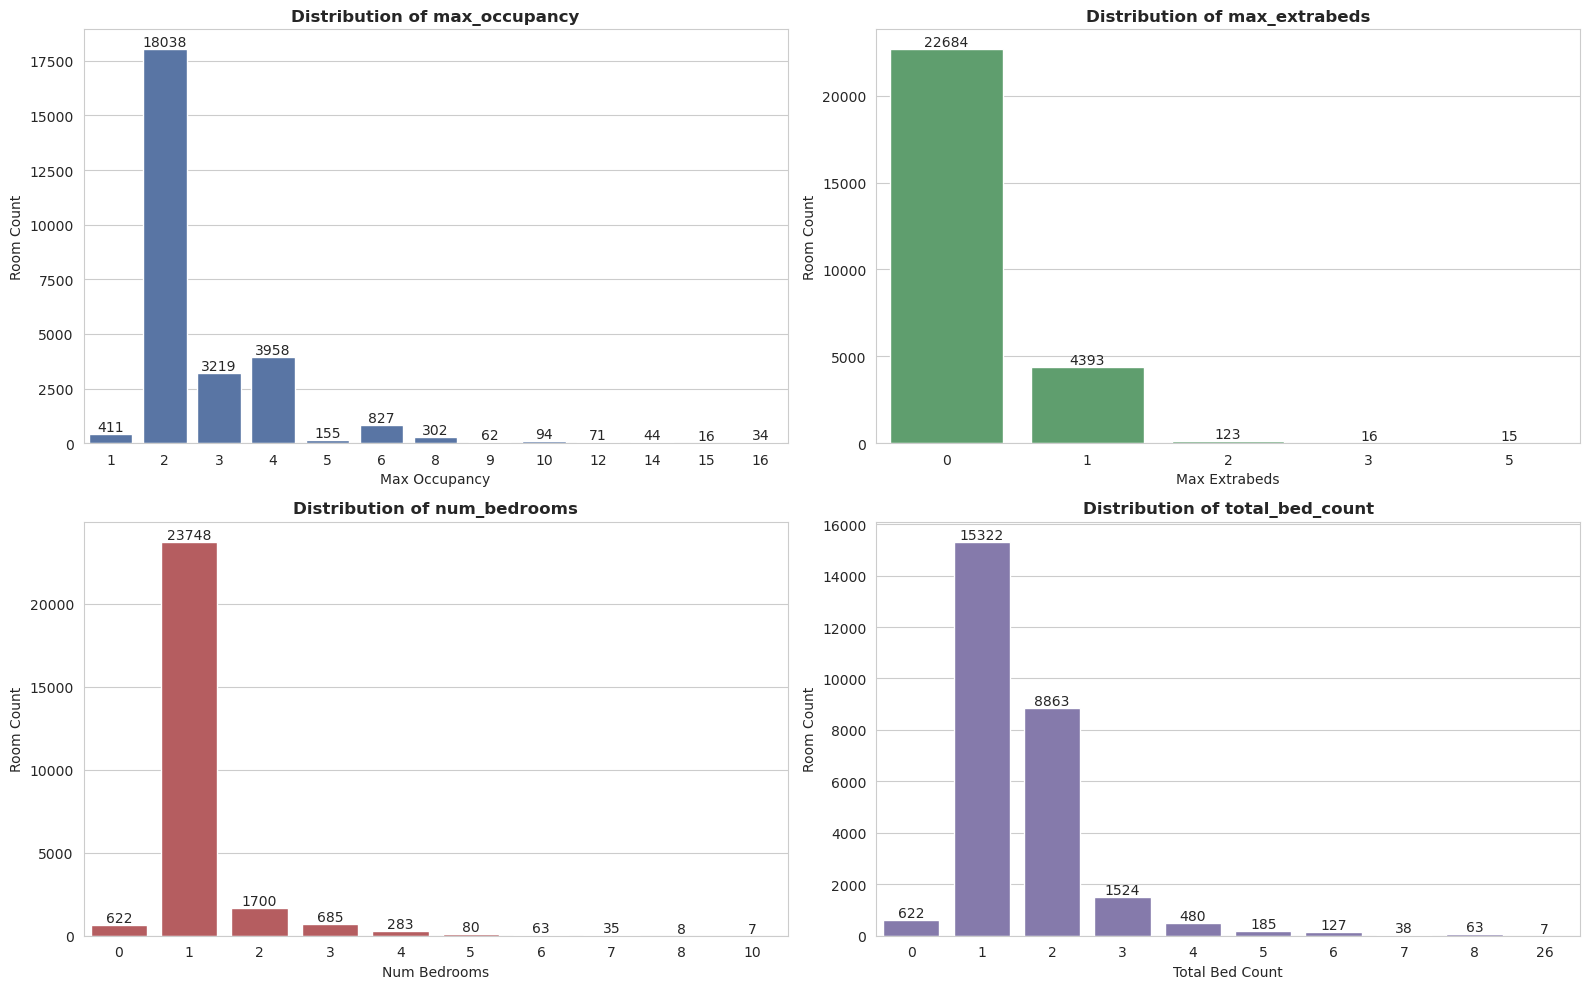

Maximum Occupancy
   - Most common (Mode): 2 guests
   - Percentage of 2-guest rooms: 66.2%
   - Percentage of 4-guest rooms: 14.5%


In [33]:
visualize_physical_attributes(df_rooms)

Phân tích phân phối tần suất của biến `max_occupancy` cho thấy sự tập trung rõ rệt vào các mô hình lưu trú quy mô nhỏ. Cụ thể, phòng dành cho 2 người (Standard Double/Twin Room) là loại hình phổ biến nhất (Mode = 2), chiếm tới 66.2% tổng số lượng phòng trong tập dữ liệu. Kết quả này phản ánh đặc thù cốt lõi của ngành khách sạn truyền thống, vốn tối ưu hóa thiết kế cho các đối tượng khách du lịch là cặp đôi (Couples) hoặc khách công tác (Business travelers).

Phân khúc phòng dành cho nhóm khách gia đình từ 4 người trở lên chiếm tỷ trọng khiêm tốn hơn. Loại phòng có sức chứa 4 người chỉ chiếm 14.5%, đứng thứ hai trong cơ cấu phân phối. Khoảng chênh lệch lớn giữa nhóm 2 người ($\approx$18,000 phòng) và nhóm 4 người ($\approx$4,000 phòng) cho thấy sự khan hiếm tương đối của các sản phẩm lưu trú cỡ lớn, hạn chế khả năng đáp ứng nhu cầu nhóm khách gia đình hoặc nhóm du lịch đông người.

Sự thống trị của phân khúc 2 người được củng cố bởi phân tích dữ liệu về số phòng ngủ (`num_bedrooms`), trong đó loại hình 1 phòng ngủ chiếm đa số tuyệt đối (hơn 23,700 mẫu). Bên cạnh đó, dữ liệu về giường phụ (`max_extrabeds`) cho thấy phần lớn các phòng ($\approx$22,600 mẫu) không hỗ trợ kê thêm giường, hạn chế khả năng linh hoạt phục vụ nhóm khách lớn.

Thị trường khảo sát thể hiện rõ xu hướng phục vụ phân khúc vi mô (micro-segment) với sức chứa chủ yếu là 2 người/phòng. Đối với các chiến lược kinh doanh, kết quả này gợi ý rằng nhu cầu tìm kiếm phòng cho đại gia đình hoặc nhóm từ 5-6 người trở lên sẽ gặp khó khăn về nguồn cung, mở ra cơ hội tiềm năng cho các mô hình lưu trú thay thế.

**Nhóm đặc trưng tiện nghi (Room Facilities - `RoomFac_columns`)**

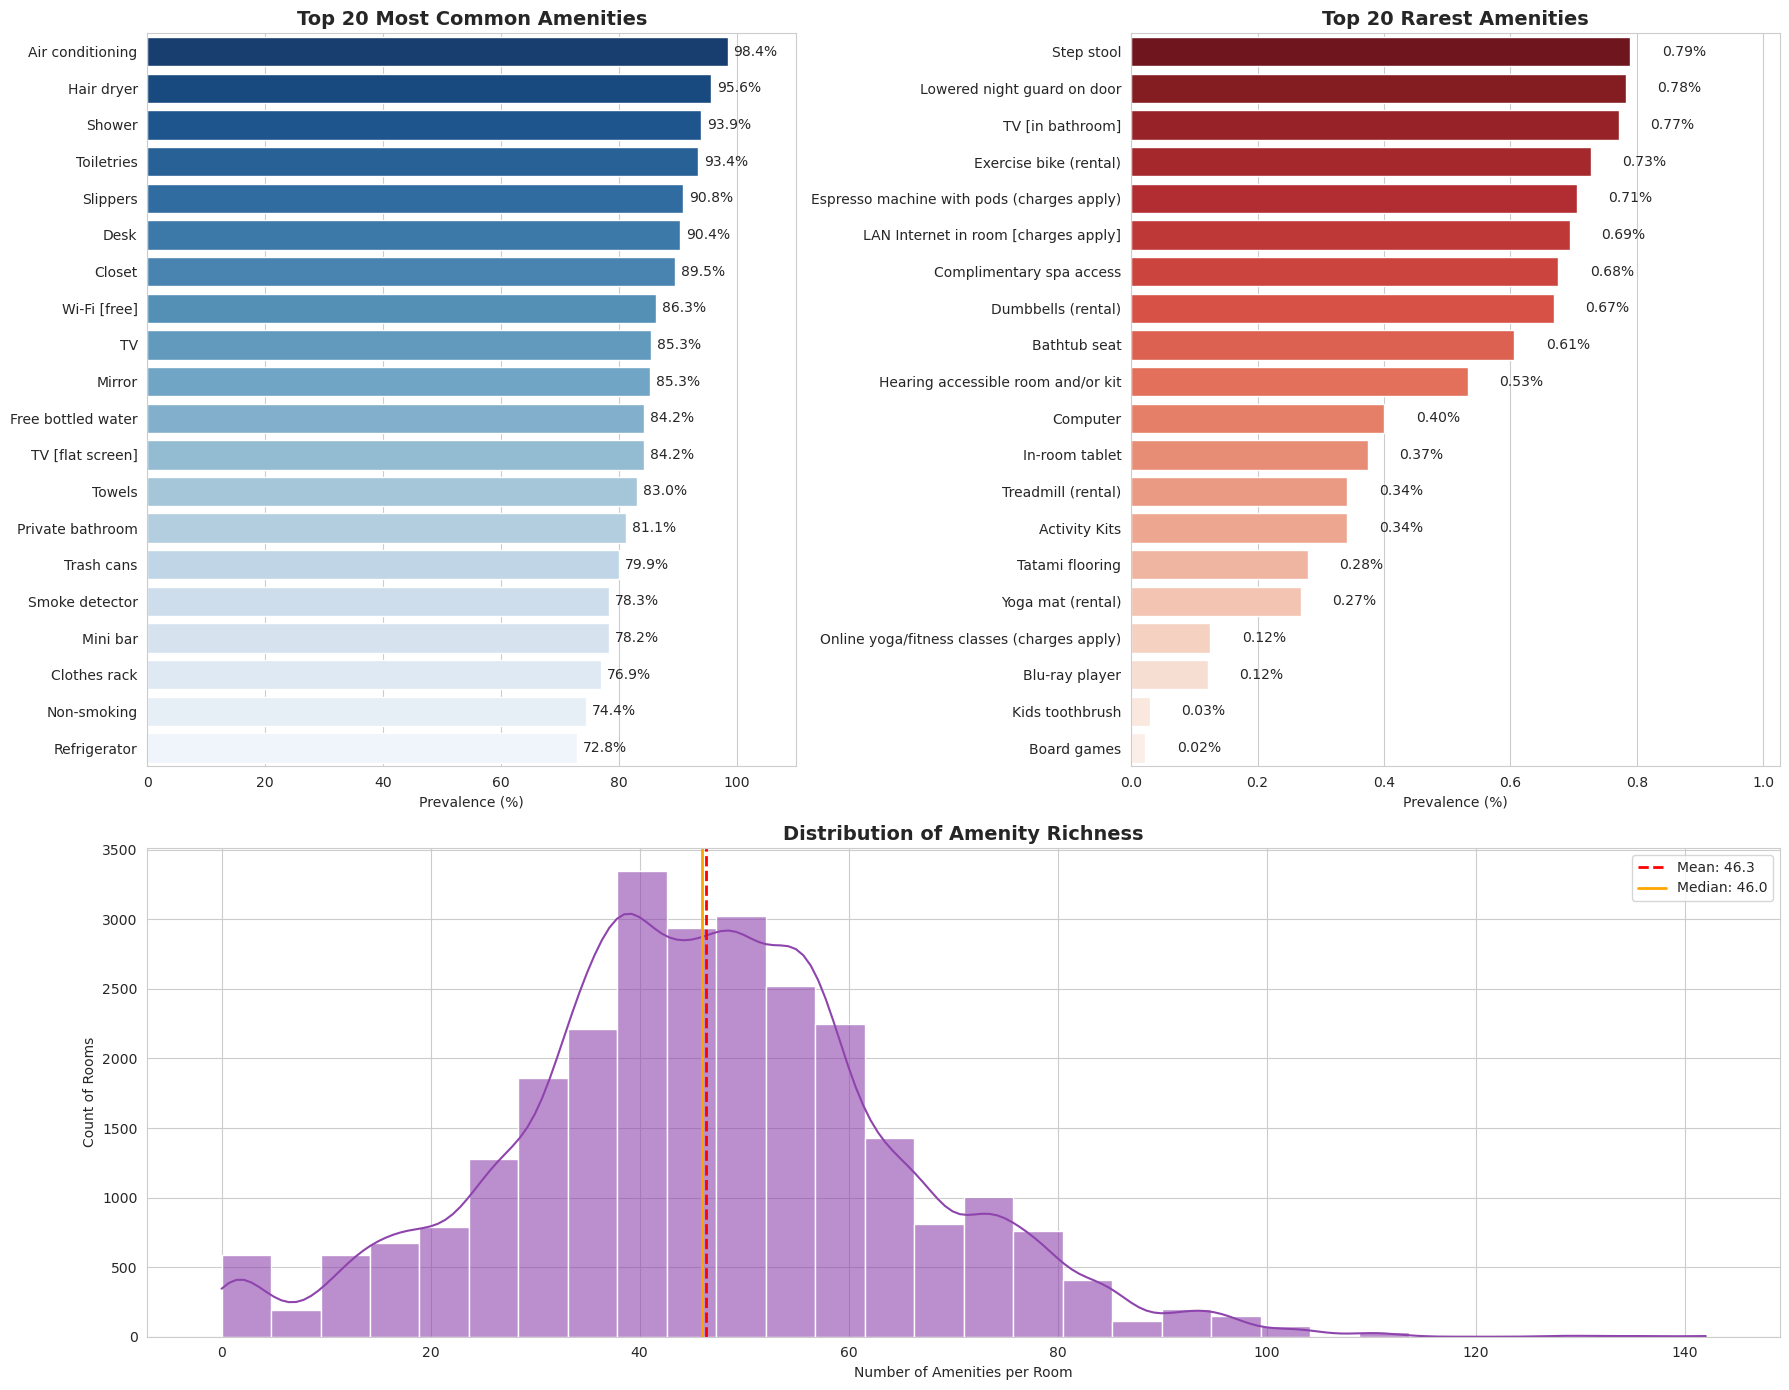

Overall Ecosystem Summary:
   - Total amenity types tracked: 187
   - Average amenities per room: 46.3
   - Standard deviation: 18.69

Amenity Hierarchy (Prevalence Levels):
   - Standard (>80% prevalence): 14 amenities
     (Core features: Wi-Fi, AC, essential room utilities)
   - Common (30 – 80%): 37 amenities
     (Basic competitive differentiators)
   - Rare (<5%): 56 amenities
     (Luxury-only features: private pool, sauna, in-room spa)


In [34]:
visualize_amenities(df_rooms)

Phân tích trên 187 loại tiện nghi được thu thập cho thấy hệ sinh thái dịch vụ phòng khách sạn có tính đa dạng cao nhưng phân tán mạnh theo từng cơ sở lưu trú. Trung bình một phòng khách sạn cung cấp 46.3 tiện nghi, với độ lệch chuẩn 18.69, cho thấy sự khác biệt đáng kể trong cấu hình tiện ích giữa các khách sạn. Phân phối Amenity Richness thể hiện dạng phân phối chuẩn, tập trung chủ yếu ở khoảng 30–60 tiện nghi/phòng, qua đó gợi ý sự tồn tại về số lượng tiện nghi tối thiểu cần thiết để duy trì khả năng cạnh tranh trên thị trường OTA.

Dựa trên tần suất xuất hiện, các tiện nghi được phân tầng thành ba nhóm rõ ràng, phản ánh chiến lược định vị sản phẩm của từng cơ sở lưu trú:

* **Nhóm Tiện nghi Cốt lõi (Standard Amenities, >80%):**
  Chỉ 14 tiện nghi đạt tỷ lệ phổ biến trên 80%, bao gồm Điều hòa (98.4%), Máy sấy tóc (95.6%), Vòi sen (93.9%) và Wi-Fi miễn phí (86.3%). Đây là nhóm commoditized features, đại diện cho các tiện ích mà khách hàng mặc định kỳ vọng. Sự thiếu vắng bất kỳ tiện nghi nào thuộc nhóm này có thể gây tác động tiêu cực ngay lập tức tới mức độ hài lòng của khách lưu trú.

* **Nhóm Tiện nghi Cạnh tranh (Common Amenities, 30–80%):**
  Gồm 37 tiện nghi, như Tủ lạnh, Két an toàn, Minibar. Đây là nhóm đặc trưng tạo nên sự khác biệt giữa phân khúc bình dân và trung cấp, đồng thời phản ánh chiến lược đầu tư mang tính “nâng chuẩn” dịch vụ của nhiều khách sạn nhắm tới phân khúc tầm trung.

* **Nhóm Tiện nghi Đặc quyền (Luxury/Rare Amenities, <5%):**
  Có tới 56 tiện nghi thuộc nhóm hiếm gặp, bao gồm Private Pool, Sauna, In-room Spa. Mặc dù mức độ phổ biến thấp nhưng chính sự khan hiếm này khiến chúng trở thành Unique Selling Points (USP), đóng vai trò thiết yếu trong việc định vị các sản phẩm cao cấp và tạo lợi thế cạnh tranh khác biệt trong thị trường Luxury Hospitality.

Kết quả phân tích cho thấy sự khác biệt về giá phòng (base_price) giữa các phân khúc khách sạn nhiều khả năng được thúc đẩy bởi sự xuất hiện của các tiện nghi đặc quyền (Rare Amenities) hơn là số lượng tiện nghi tổng thể. Do đó, trong các mô hình dự báo giá, các biến nhị phân đại diện cho tiện nghi hiếm — chẳng hạn như *Has_Private_Pool* hoặc *Has_Sauna* — được kỳ vọng mang trọng số dương mạnh hơn so với biến tổng hợp *Total_Amenities*. Điều này khẳng định vai trò chiến lược của các tiện nghi hiếm trong việc tạo dựng định vị và tối ưu hóa giá trị kinh tế của dịch vụ lưu trú.

**Tác động của tiện nghi ảnh hưởng như thế nào đến giá phòng?**

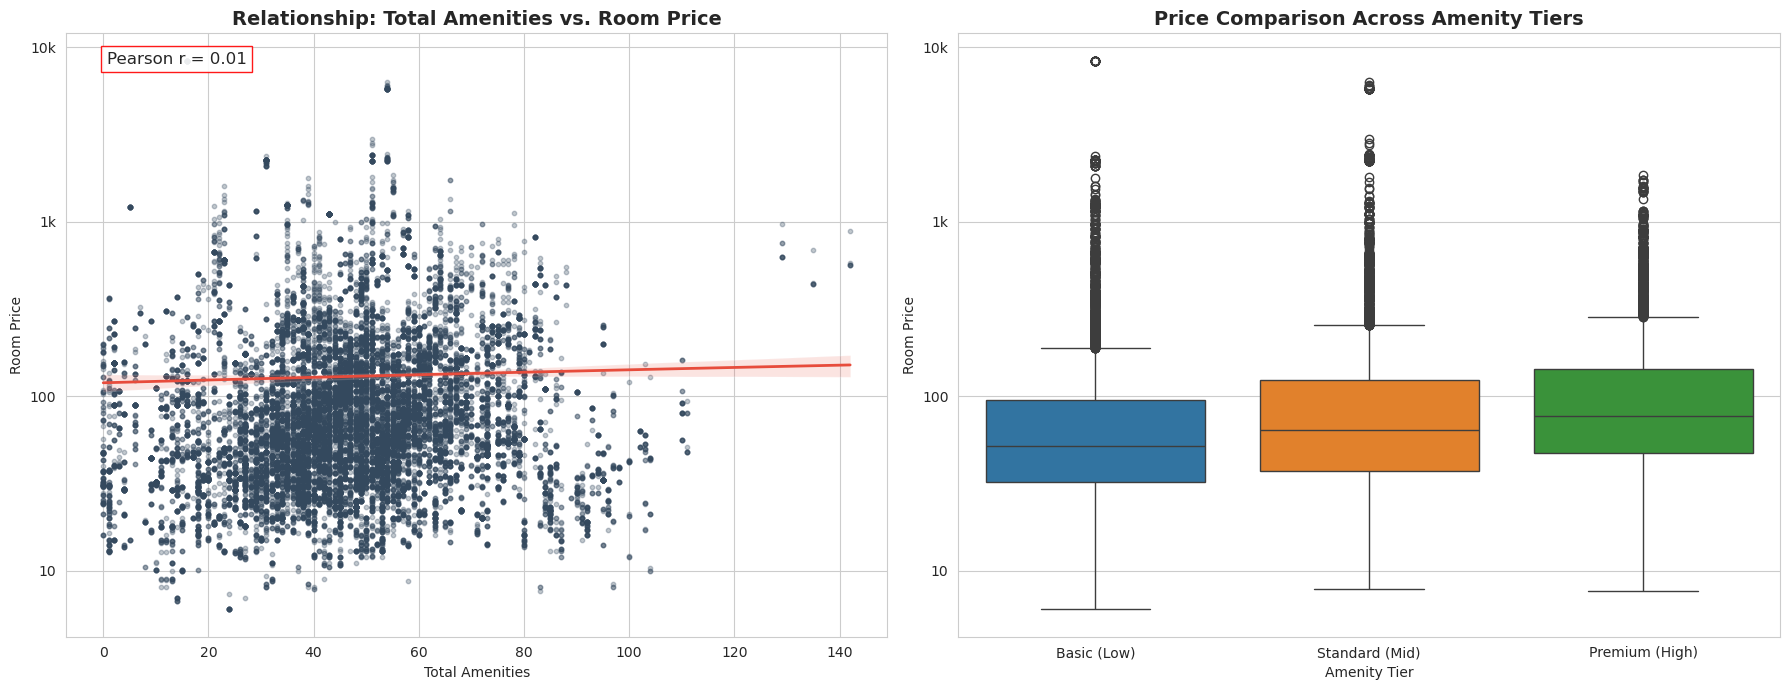


Correlation Strength:
   Pearson r = 0.012
   Interpretation: WEAK correlation.

Value Gap Analysis:
 Median price (Basic):   51,440 VND
 Median price (Premium): 77,190 VND
=> PRICE GAP: Premium rooms are about 50.1% more expensive.


In [35]:
analyze_amenity_price_relation(df_rooms)

Kết quả phân tích tương quan Pearson giữa biến `Total_Amenities` và `base_price` cho thấy hệ số tương quan đạt mức r = 0.012, một giá trị gần như bằng không. Về mặt thống kê, điều này chỉ ra rằng không tồn tại mối quan hệ tuyến tính đáng kể giữa số lượng tiện nghi và giá phòng. Nói cách khác, chiến lược tăng số lượng tiện nghi trong một phòng không tạo ra tác động tuyến tính lên mức giá. Một phòng sở hữu 90–100 tiện nghi không nhất thiết có giá cao hơn phòng chỉ có 40–50 tiện nghi nếu xét toàn bộ thị trường.

Mặc dù tương quan tuyến tính yếu, sự khác biệt lại trở nên rõ ràng khi phân tầng các phòng theo nhóm tiện nghi. So sánh trung vị giữa hai phân khúc cho thấy:

* **Nhóm Basic (ít tiện nghi)** có median giá phòng là 51.
* **Nhóm Premium (nhiều tiện nghi)** có median giá phòng là 77.

Khoảng cách này tương đương Price Gap = 50.1%, cho thấy việc định vị sản phẩm trong phân khúc tiện nghi cao hơn mang lại giá sàn (price floor) cao hơn đáng kể. Như vậy, giá trị của tiện nghi không đến từ từng tiện ích riêng lẻ mà từ gói dịch vụ tổng thể và mức độ hoàn chỉnh của trải nghiệm khách hàng mà khách sạn cung cấp.


Sự đối lập giữa hệ số tương quan cực thấp và chênh lệch giá trị rất lớn giữa các phân khúc cho thấy mối quan hệ giữa tiện nghi và giá phòng mang tính phi tuyến (non-linear) và chịu tác động của ngưỡng hiệu lực (threshold effect). Các khách sạn chỉ khi đạt đến một mức độ tiện nghi nhất định mới có khả năng dịch chuyển sang phân khúc giá cao hơn, thay vì tăng từng tiện nghi nhỏ lẻ mà kỳ vọng giá sẽ tăng theo.

**Analysis of Categorical Columns**


   ANALYZING COLUMN: ROOM_NAME
Unique Values: 1303
Missing Values: 0 (0.00%)
Most Frequent: 'Apartment' (427 occurrences)

   ANALYZING COLUMN: ROOM_SIZE
Unique Values: 134
Missing Values: 595 (2.19%)
Most Frequent: 'Room size: 30 m²/323 ft²' (2770 occurrences)
 % Entries containing numbers: 100.0%
 % Entries containing measurement units (m²/sqm): 100.0%

   ANALYZING COLUMN: BED_CONFIGURATION
Unique Values: 168
Missing Values: 622 (2.28%)
Most Frequent: '1 x 1 king bed' (5739 occurrences)


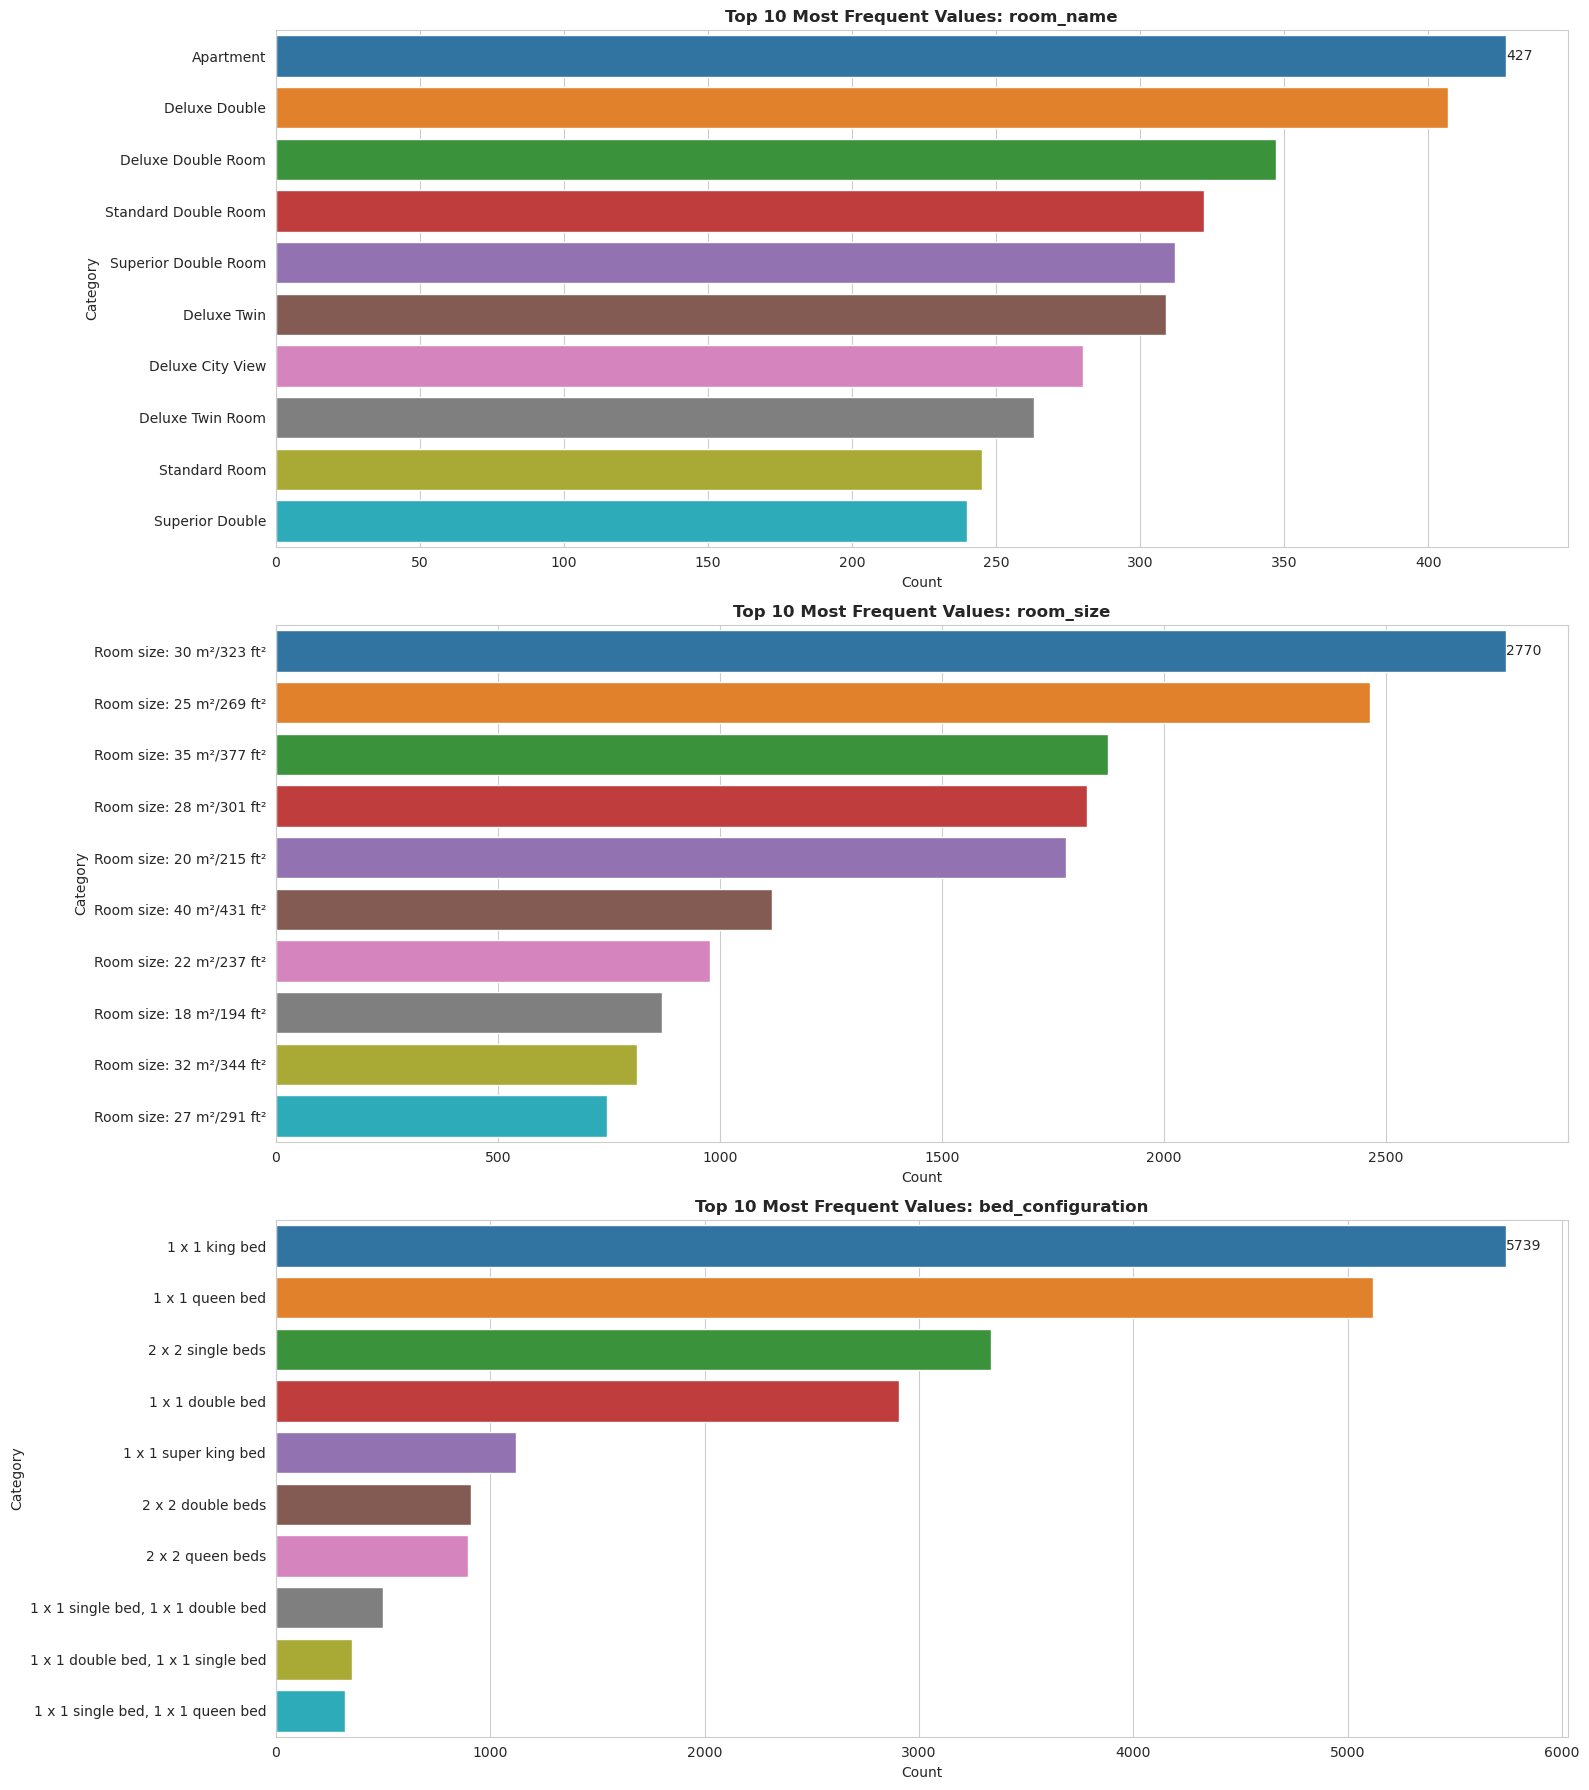

In [36]:
analyze_categorical_text(df_rooms)

Trước hết, biến `room_name` ghi nhận tới 1303 giá trị duy nhất, phản ánh sự thiếu chuẩn hóa trong quy ước đặt tên phòng giữa các cơ sở lưu trú. Mặc dù dữ liệu không có giá trị khuyết, sự sai lệch ngữ nghĩa thể hiện rõ qua các nhãn khác biệt nhưng cùng mô tả một loại phòng, như *Deluxe Double* và *Deluxe Double Room*. Điều này đặt ra yêu cầu cần thiết cho các bước tiền xử lý văn bản nhằm chuẩn hóa và gom nhóm các tên phòng về các hạng mục thống nhất (Standard, Deluxe, Suite, Apartment), qua đó giảm nhiễu và nâng cao chất lượng mô hình hóa sau này.

Đối với biến `room_size`, dữ liệu có mức độ hoàn thiện cao với tỷ lệ thiếu chỉ 2.19% và toàn bộ các mục nhập đều chứa thông tin diện tích hợp lệ. Kích thước phổ biến nhất là 30 $m^2$, phản ánh chuẩn diện tích của phân khúc trung cấp. Tuy nhiên, định dạng dữ liệu dưới dạng chuỗi hỗn hợp (ví dụ: Room size: 30 m²/323 ft²) yêu cầu phải tách xuất thông tin bằng kỹ thuật Regular Expressions để chuyển đổi sang biến số dạng số thực (float), đảm bảo khả năng sử dụng trong mô hình hồi quy định lượng.

Tương tự, biến `bed_configuration` thể hiện cấu trúc đa dạng với 168 kiểu mô tả, nhưng vẫn duy trì chất lượng tốt với tỷ lệ thiếu 2.28%. Loại giường phổ biến nhất là *1 x 1 king bed*, cho thấy sự ưu tiên của thị trường đối với giường lớn phục vụ cặp đôi và khách doanh nhân. Để phục vụ phân tích định lượng và học máy, cần thiết phải tách thông tin này thành các biến thành phần như `Bed_Type` và `Bed_Count`, từ đó giúp mô hình nhận diện được sự khác biệt về giá giữa các cấu hình giường (ví dụ: hai giường đơn thường có mức giá thấp hơn một giường King).

Tổng quan cho thấy dữ liệu văn bản tuy có tỷ lệ thiếu thấp (<3%), nhưng mức độ không đồng nhất cao đòi hỏi quy trình làm sạch và chuẩn hóa nghiêm ngặt. Việc tiền xử lý đúng đắn sẽ đóng vai trò quyết định trong việc giảm sai lệch ngữ nghĩa, cải thiện khả năng trích xuất đặc trưng (feature extraction), và tăng độ chính xác của các mô hình định giá phòng ở các bước phân tích tiếp theo.

## **C. Tours data**

### **1. Load raw data**

Các dữ liệu thô của tour ban đầu được chúng em crawl từ GraphQL API backend của Agoda và lưu ở thư mục data/raw. Có 2 file csv được lưu về là tour_list.csv và tours_price vì Agoda dùng 1 API riêng để list thông tin phòng và 1 API để lấy giá tương lai.

In [37]:
# Load data
tours_list = pd.read_csv("../data/raw/tours_list.csv")
tours_prices = pd.read_csv("../data/raw/tours_prices.csv")

### **2. Basic information**


Lấy 5 dòng đầu của mỗi file để có cái nhìn chung về data.

In [38]:
tours_list.head()

,activity_id,activity_token,name,city,categories,description,latitude,longitude,address,rating_score,total_bookings,price_from,currency,crawled_at
0,1041565,AAABuOF7Im1haWQiOm51bGwsIgsAoDEwNDE1NjUsInMOAP...,My Xuan Night Cruise on Han River in Da Nang |...,Da Nang,Tours,Enjoy a fun ride along the charming Han River ...,0.000000,0.000000,NaN,4.3,525,96857.0,VND,2025-11-28 23:18:22
1,1148513,AAABw-F7Im1haWQiOm51bGwsIgsAoDExNDg1MTMsInMOAE...,Han River by Night on My Xuan Cruise in Da Nang,Da Nang,"Tours, FoodAndDrinks",- Have a relaxing night in Da Nang and hop on ...,16.068366,108.219195,NaN,4.4,511,108804.0,VND,2025-11-28 23:18:22
2,1170671,AAABveF7Im1haWQiOm51bGwsIgsAoDExNzA2NzEsInMOAP...,Ba Na Hills By Night And Golden Bridge with Bu...,Da Nang,"FoodAndDrinks, Tours",Explore a unique night experience with our spe...,0.000000,0.000000,NaN,3.8,77,467930.0,VND,2025-11-28 23:18:22
3,1204350,AAABveF7Im1haWQiOm51bGwsIgsAoDEyMDQzNTAsInMOAP...,Hoi An Ancient Town & Coconut Forest Basket Bo...,Da Nang,Tours,Discover the charm of Hoi An Ancient Town and ...,0.000000,0.000000,NaN,4.7,73,816726.0,VND,2025-11-28 23:18:22
4,1147442,AAABw-F7Im1haWQiOm51bGwsIgsAoDExNDc0NDIsInMOAP...,"Son Tra Peninsula, Marble Mountain, and Hoi An...",Da Nang,Tours,* Admire the tallest Buddha statue in the Son ...,16.068366,108.219195,NaN,4.4,189,625742.0,VND,2025-11-28 23:18:22


In [39]:
tours_prices.head()

,activity_id,travel_date,is_available,price,original_price,currency,crawled_at,is_anchor
0,1041565,2025-12-12,True,119715.0,127901.0,VND,2025-11-29 00:08:43,False
1,1041565,2025-12-21,True,105620.0,117880.0,VND,2025-11-29 00:08:43,False
2,1041565,2025-12-29,True,98799.0,107859.0,VND,2025-11-29 00:08:45,False
3,1041565,2026-01-01,False,NaN,NaN,VND,2025-11-29 00:08:46,False
4,1041565,2026-01-15,False,NaN,NaN,VND,2025-11-29 00:08:46,False


**Số dòng, số cột của các file**

In [40]:
print(f"   - tours_list.csv: {tours_list.shape[0]:,} rows × {tours_list.shape[1]} columns")
print(f"   - tours_prices.csv: {tours_prices.shape[0]:,} rows × {tours_prices.shape[1]} columns")

   - tours_list.csv: 808 rows × 14 columns
   - tours_prices.csv: 17,610 rows × 8 columns


Danh sách các tour gồm 808 dòng và 14 cột. Danh sách giá tour theo ngày gồm 17.610 dòng và 8 thuộc tính. Vì data tours được crawl bằng GraphQL API backend của Agoda nên các thuộc tính được trả về sẽ là những thuộc tính chúng em request. Tổng thể các thuộc tính sẽ là thuộc tính cần thiết để chúng em phân tích nâng cao.

**Check duplicate data**

Để đảm bảo tính toàn vẹn của tập dữ liệu, chúng em đã tiến hành kiểm tra toàn diện các bản ghi trùng lặp trên tất cả các thuộc tính bằng hàm duplicated trong Pandas.

In [41]:
# Kiểm tra duplicates hoàn toàn
dup_list_full = tours_list.duplicated().sum()
dup_prices_full = tours_prices.duplicated().sum()

print("\n tours_list:")
print(f"   • Số dòng trùng lặp hoàn toàn: {dup_list_full}")

print("\n tours_prices:")
print(f"   • Số dòng trùng lặp hoàn toàn: {dup_prices_full}")


 tours_list:
   • Số dòng trùng lặp hoàn toàn: 0

 tours_prices:
   • Số dòng trùng lặp hoàn toàn: 0


Kết quả là không có hàng nào trùng lặp hoàn toàn.

**Missing values**

In [42]:
print(" TỶ LỆ GIÁ TRỊ BỊ THIẾU (MISSING VALUES)")

def missing_values_table(df, df_name):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    mis_val_table = pd.DataFrame({
        'Số lượng Missing': mis_val,
        'Tỷ lệ (%)': mis_val_percent.round(2)
    })

    # Sắp xếp theo tỷ lệ giảm dần
    mis_val_table = mis_val_table.sort_values('Tỷ lệ (%)', ascending=False)

    print(f"\n{df_name}:")
    display(mis_val_table)

    return mis_val_table

missing_list = missing_values_table(tours_list, "tours_list")
missing_prices = missing_values_table(tours_prices, "tours_prices")

 TỶ LỆ GIÁ TRỊ BỊ THIẾU (MISSING VALUES)

tours_list:


,Số lượng Missing,Tỷ lệ (%)
address,808,100.0
activity_id,0,0.0
activity_token,0,0.0
name,0,0.0
city,0,0.0
categories,0,0.0
description,0,0.0
latitude,0,0.0
longitude,0,0.0
rating_score,0,0.0



tours_prices:


,Số lượng Missing,Tỷ lệ (%)
price,3283,18.64
original_price,3283,18.64
activity_id,0,0.00
travel_date,0,0.00
is_available,0,0.00
currency,0,0.00
crawled_at,0,0.00
is_anchor,0,0.00


Đối với danh sách tours thì thuộc tính *address* có 100% missing,
nghĩa là thuộc tính này không được trả về khi call API của Agoda. Nhưng chúng ta có thuộc tính lat/lon để lấy được vị trí cho tour. Còn lại các cột khác trong danh sách tours đều không có missing value.

Đối với danh sách giá tour theo ngày thì có *original_price* với 18.64% missing và 0% với các thuộc tính còn lại.

Nhìn chung thì các thuộc tính khá đầy đủ ngoại trừ *address* missing 100% do không được trả về từ api call.

### **3. Data sematics**


#### **Ý nghĩa của mỗi dòng**

Đối với tour list, mỗi dòng đại diện cho một tour du lịch duy nhất trên Agoda, chứa thông tin tĩnh *như tên, vị trí, rating, giá khởi điểm, mô tả* hay các thông tin vị trí địa như *lat lon*

Đối với tour price, mỗi dòng đại diện cho giá của tour được liệt kê trong tour list ở các ngày cụ thể. Một tour có nhiều giá cho nhiều ngày khác nhau.

#### **Ý nghĩa của mỗi cột**

In [43]:
dfs = {
    "tours_list": tours_list,
    "tours_prices": tours_prices
}

for name, df in dfs.items():
    print(f"- **Shape:** {df.shape}")
    print(f"- **Columns:** {list(df.columns)}")
    print("\n---\n")

- **Shape:** (808, 14)
- **Columns:** ['activity_id', 'activity_token', 'name', 'city', 'categories', 'description', 'latitude', 'longitude', 'address', 'rating_score', 'total_bookings', 'price_from', 'currency', 'crawled_at']

---

- **Shape:** (17610, 8)
- **Columns:** ['activity_id', 'travel_date', 'is_available', 'price', 'original_price', 'currency', 'crawled_at', 'is_anchor']

---



**A. Identity & Temporal Context (Định danh & Thời gian)**
* **`activity_id`, `activity_token`**: Mã định danh duy nhất cho từng sản phẩm tour. Đây là khóa chính để liên kết các đặc tính tĩnh với dữ liệu giá động.
* **`travel_date`**: Biến thời gian quan trọng nhất. Nó cho phép mô hình nắm bắt được **tính mùa vụ (seasonality)**, xu hướng ngày lễ/cuối tuần – yếu tố then chốt quyết định sự dao động của giá trong ngành du lịch.

**B. Geospatial & Categorical Attributes** (Không gian & Phân loại)
Khác với phòng khách sạn (cố định), tour du lịch gắn liền với trải nghiệm và sự dịch chuyển.
* **`city`, `latitude`, `longitude`**: Định vị tọa độ chính xác. Các biến này không chỉ xác định vị trí mà còn là đầu vào để tính toán **"địa tô" (location rent)** hoặc khoảng cách đến các điểm nóng (POI).
* **`categories`**: Phân loại tour (ví dụ: *FoodAndDrinks, Adventure*). Đây là biến định tính quan trọng để phân khúc thị trường, vì **độ nhạy về giá (price elasticity)** của khách hàng đối với một "Food Tour" sẽ hoàn toàn khác với một "Luxury Cruise".

**C. Quality & Performance Signals (Tín hiệu Chất lượng & Hiệu suất)**
* **`rating_score`**: Thước đo trực tiếp sự hài lòng của khách hàng. Trong mô hình, biến này đóng vai trò "kiểm soát chất lượng" – giải thích lý do tại sao một tour giá cao vẫn có thể bán chạy (High Price - High Quality correlation).
* **`total_bookings`**: Một biến proxy (đại diện) mạnh mẽ cho độ phổ biến (popularity) và niềm tin thị trường. Tour có lượng booking lịch sử lớn thường có **vị thế định giá (pricing power)** tốt hơn.

**D. Semantic Content (Ngữ nghĩa nội dung)**
Đây là điểm khác biệt lớn nhất so với dữ liệu khách sạn truyền thống.
* **`description`**, **`name`**: Chứa dữ liệu văn bản phi cấu trúc (unstructured text). Đây là tài nguyên để trích xuất đặc trưng (feature extraction) về mức độ cao cấp hay tính độc đáo.
    * *Ví dụ:* Sự xuất hiện của các từ khóa như *"Private", "Luxury", "Buffet"* trong mô tả thường tương quan thuận với mức giá cao hơn (Price Premium).

**E. Economic Dynamics & Availability (Động lực Kinh tế & Cung ứng)**
Đây là nhóm biến mục tiêu (Target) và biến điều khiển chính:
* **`price` (Selling Price)** & **`original_price` (Retail Price)**: Cặp biến này hé lộ **chiến lược chiết khấu (discount strategy)**. Khoảng chênh lệch (Gap) giữa hai mức giá là tín hiệu kích thích cầu.
* **`price_from`**: Mức giá sàn hoặc giá tham chiếu (Anchor Price), giúp định hình kỳ vọng ban đầu của khách hàng.

#### Kiểu dữ liệu của mỗi cột

In [44]:
print(" KIỂU DỮ LIỆU CỦA MỖI CỘT")

def analyze_dtypes(df, df_name):
    print(f"\n {df_name}:")
    print("-" * 60)

    suggestions = []
    for col in df.columns:
        dtype = df[col].dtype
        sample = df[col].dropna().iloc[0] if df[col].notna().any() else "N/A"

        # Truncate sample if too long
        sample_str = str(sample)[:50] + "..." if len(str(sample)) > 50 else str(sample)

        print(f"  {col:20s} | {str(dtype):12s} | Sample: {sample_str}")

    return suggestions

suggestions_list = analyze_dtypes(tours_list, "tours_list")
suggestions_prices = analyze_dtypes(tours_prices, "tours_prices")


 KIỂU DỮ LIỆU CỦA MỖI CỘT

 tours_list:
------------------------------------------------------------
  activity_id          | int64        | Sample: 1041565
  activity_token       | object       | Sample: AAABuOF7Im1haWQiOm51bGwsIgsAoDEwNDE1NjUsInMOAPAHNT...
  name                 | object       | Sample: My Xuan Night Cruise on Han River in Da Nang | Vie...
  city                 | object       | Sample: Da Nang
  categories           | object       | Sample: Tours
  description          | object       | Sample: Enjoy a fun ride along the charming Han River in D...
  latitude             | float64      | Sample: 0.0
  longitude            | float64      | Sample: 0.0
  address              | float64      | Sample: N/A
  rating_score         | float64      | Sample: 4.3
  total_bookings       | int64        | Sample: 525
  price_from           | float64      | Sample: 96857.0
  currency             | object       | Sample: VND
  crawled_at           | object       | Sample: 2025-11-28 

Kết quả rà soát cấu trúc dữ liệu trên hai bảng tours_list và tours_prices cho thấy sự phân hóa rõ rệt giữa các nhóm biến định lượng, định tính và thời gian, phản ánh đúng độ phức tạp của bài toán định giá động:

1. Nhóm biến số học (Numerical Data - Int64/Float64) Các trường định danh và chỉ số đếm như activity_id và total_bookings được lưu trữ chuẩn xác dưới dạng số nguyên (int64), phù hợp với bản chất rời rạc của dữ liệu. Đặc biệt, nhóm biến liên quan đến tài chính và trắc lượng như price, original_price, price_from và rating_score đều có kiểu số thực (float64). Điều này là tối quan trọng cho các phép toán thống kê mô tả cũng như việc tính toán hàm mất mát (loss function) trong các mô hình hồi quy. Ngoài ra, latitude và longitude cũng ở dạng float64, sẵn sàng cho các thuật toán tính khoảng cách không gian (Haversine distance) để xác định "địa tô" của tour mà không cần chuyển đổi thêm.

2. Nhóm biến văn bản và phân loại (Object/String) Phần lớn dung lượng thông tin của bộ dữ liệu nằm ở các cột kiểu object như name, categories, description, và city. Khác với dữ liệu khách sạn thường có cấu trúc cứng, categories và description của tour chứa lượng thông tin phi cấu trúc rất lớn. Hiện tại chúng đang ở dạng chuỗi thô. Để mô hình có thể "hiểu" được, trong giai đoạn Feature Engineering, chúng ta bắt buộc phải áp dụng các kỹ thuật xử lý ngôn ngữ (như One-Hot Encoding cho city, hoặc TF-IDF/Word Embeddings cho description) để chuyển đổi các trường này thành không gian vector số học.

3. Nhóm biến thời gian (Temporal Data) Một điểm cần đặc biệt lưu ý là các cột chứa thông tin thời gian như travel_date và crawled_at hiện đang được pandas nhận diện là kiểu object (chuỗi ký tự). Đây là "vùng cần xử lý ưu tiên". Để mô hình nắm bắt được tính mùa vụ (seasonality) và xu hướng đặt trước (booking curve), các cột này bắt buộc phải được chuyển đổi (type-casting) sang định dạng datetime. Việc này sẽ cho phép trích xuất các đặc trưng dẫn xuất quan trọng như: Day_of_Week (cuối tuần vs ngày thường), Month (mùa cao điểm vs thấp điểm), hay Lead_Time (khoảng cách từ lúc thu thập dữ liệu đến ngày khởi hành).

4. Nhóm biến logic (Boolean) Dữ liệu giá tour sở hữu các cột is_available và is_anchor với kiểu dữ liệu bool (True/False). Đây là định dạng lưu trữ tối ưu nhất cho các biến nhị phân, đóng vai trò như các "công tắc" lọc dữ liệu hoặc làm biến điều kiện (conditional features) giúp mô hình phân biệt giữa trạng thái "còn hàng" và "hết hàng", hoặc giữa giá niêm yết và giá khuyến mãi.

Kết luận: Nhìn chung, hệ thống kiểu dữ liệu hiện tại khá "sạch" cho các biến số, nhưng đòi hỏi khối lượng công việc tiền xử lý (Preprocessing) đáng kể cho nhóm biến văn bản và thời gian. Chiến lược sắp tới sẽ tập trung vào việc "số hóa" các cột object này để biến dữ liệu thô thành các tín hiệu đầu vào (inputs) có ý nghĩa cho mô hình tối ưu hóa.

### **4. Distribution & Visualization**

/tmp/ipykernel_999/4059504259.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
/tmp/ipykernel_999/4059504259.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette='magma')


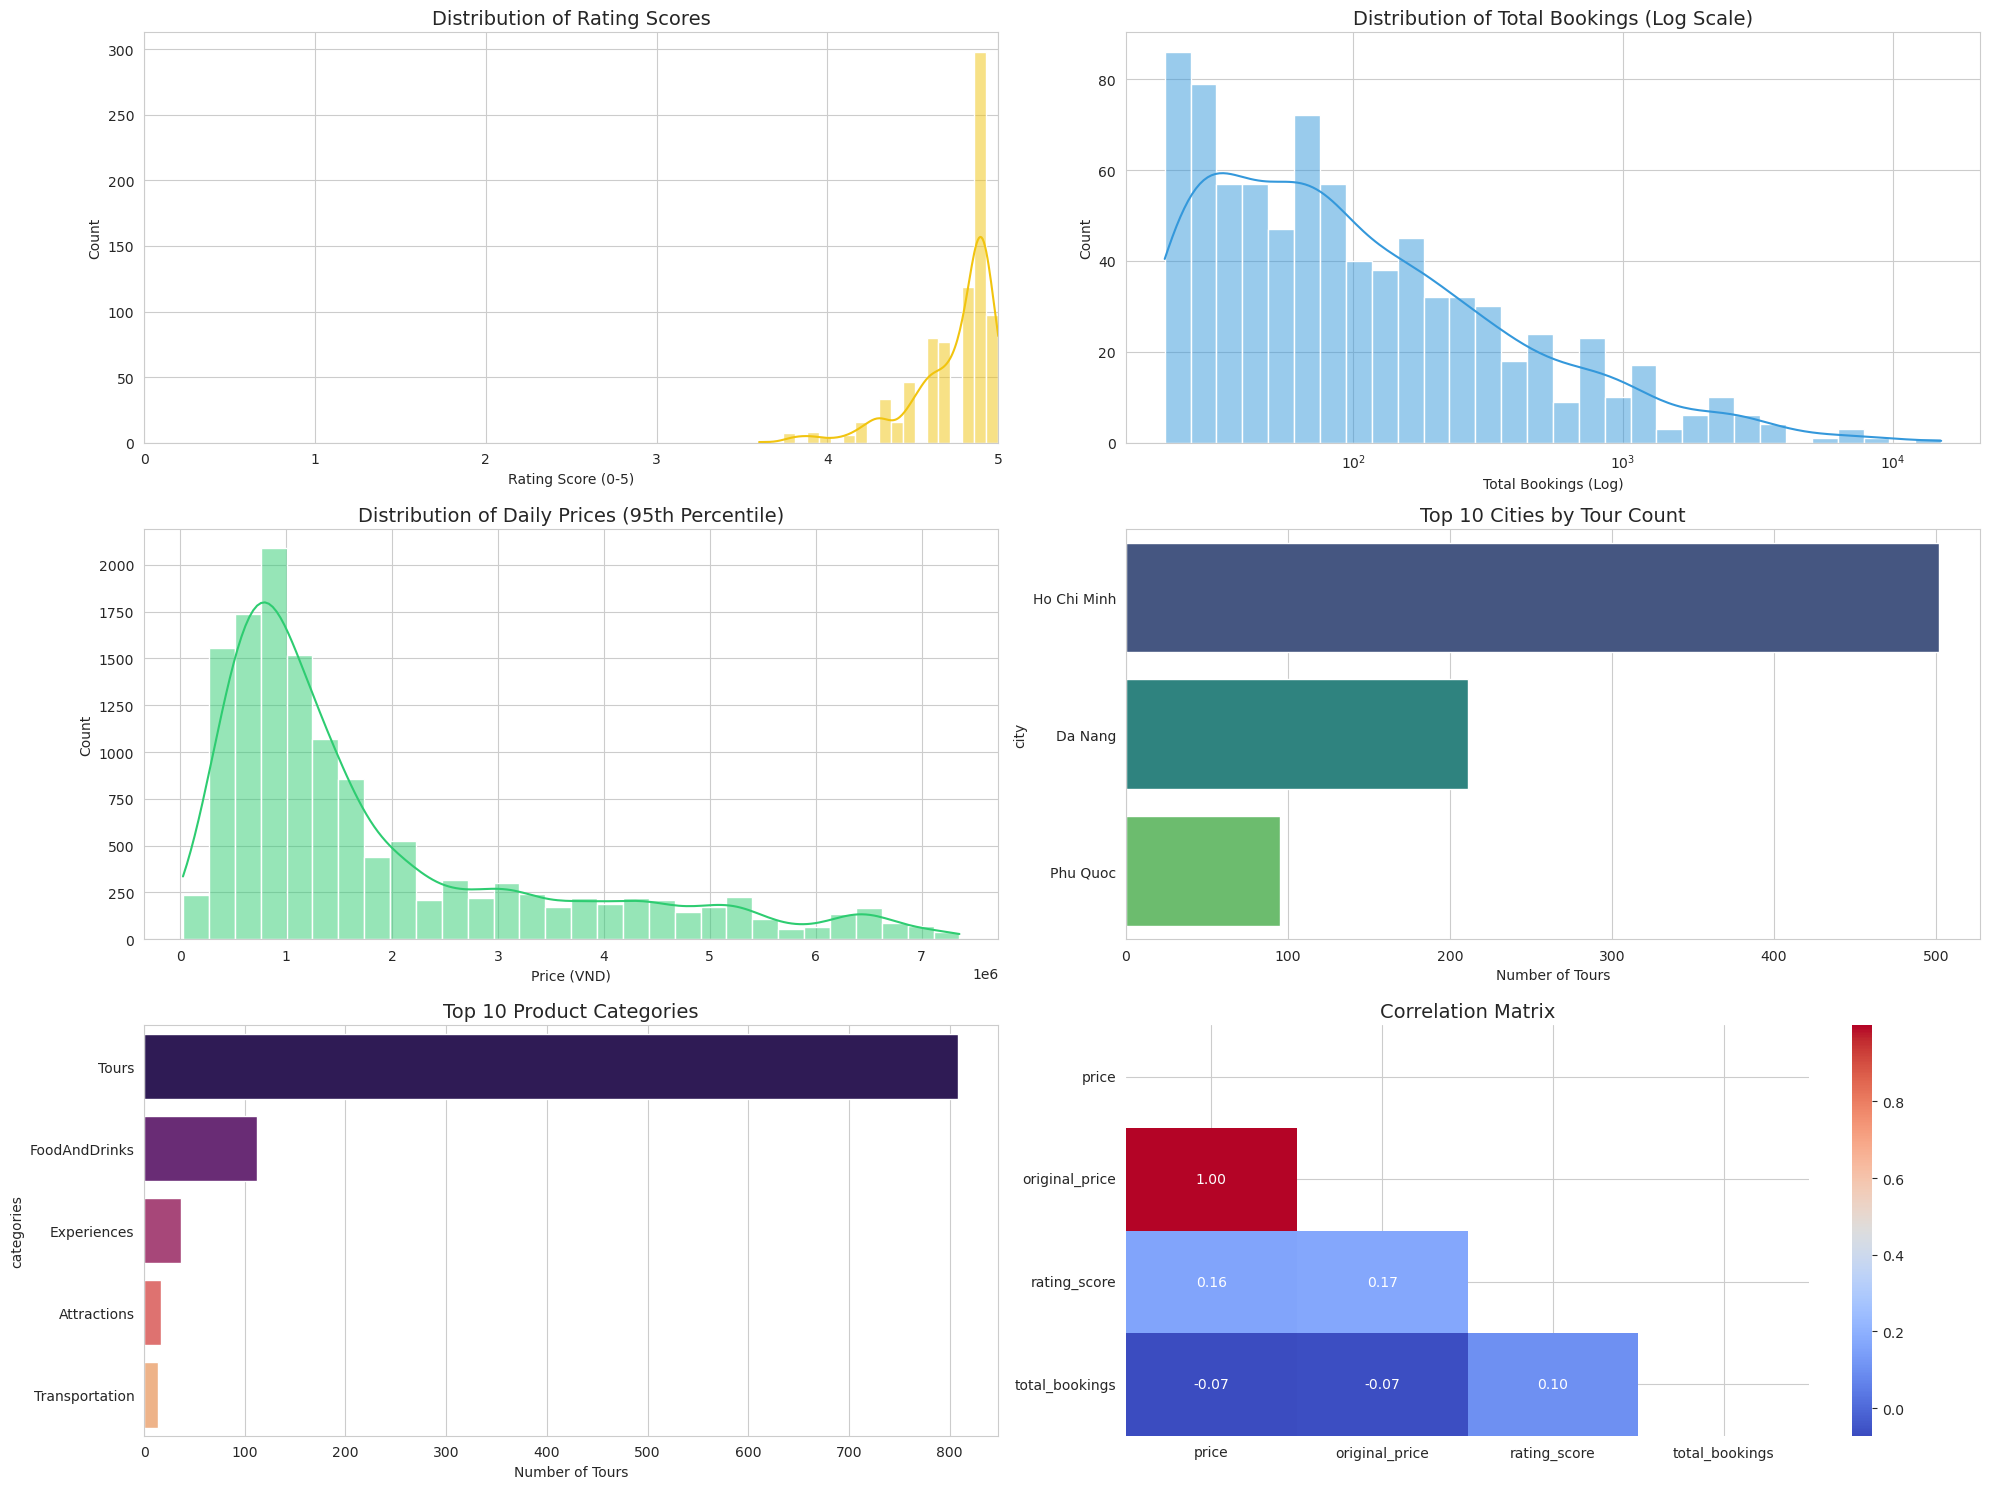

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# Reload data to ensure clean state
tours_list = pd.read_csv("../data/raw/tours_list.csv")
tours_prices = pd.read_csv("../data/raw/tours_prices.csv")

# Preprocessing
tours_prices['travel_date'] = pd.to_datetime(tours_prices['travel_date'])
# Handle is_available as both string and boolean
tours_prices['is_available_bool'] = tours_prices['is_available'].map({
    'True': True, 'False': False, True: True, False: False
})
available_prices = tours_prices[tours_prices['is_available_bool'] == True].copy()

# Setup figures
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Numeric Distribution: Rating Score
plt.subplot(3, 2, 1)
sns.histplot(tours_list['rating_score'].dropna(), bins=20, kde=True, color='#f1c40f')
plt.title('Distribution of Rating Scores', fontsize=14)
plt.xlabel('Rating Score (0-5)')
plt.xlim(0, 5)

# 2. Numeric Distribution: Total Bookings (Log Scale)
plt.subplot(3, 2, 2)
bookings_data = tours_list['total_bookings'].dropna()
bookings_data = bookings_data[bookings_data > 0]  # Filter out zeros for log scale
sns.histplot(bookings_data, bins=30, kde=True, color='#3498db', log_scale=True)
plt.title('Distribution of Total Bookings (Log Scale)', fontsize=14)
plt.xlabel('Total Bookings (Log)')

# 3. Numeric Distribution: Price (from Prices table)
plt.subplot(3, 2, 3)
price_data = available_prices['price'].dropna()
if len(price_data) > 0:
    price_limit = price_data.quantile(0.95)
    sns.histplot(price_data[price_data < price_limit], bins=30, kde=True, color='#2ecc71')
plt.title('Distribution of Daily Prices (95th Percentile)', fontsize=14)
plt.xlabel('Price (VND)')

# 4. Categorical: Top Cities
plt.subplot(3, 2, 4)
top_cities = tours_list['city'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities by Tour Count', fontsize=14)
plt.xlabel('Number of Tours')

# 5. Categorical: Top Categories
plt.subplot(3, 2, 5)
all_cats = tours_list['categories'].astype(str).str.split(',').explode().str.strip()
top_cats = all_cats.value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, palette='magma')
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Number of Tours')

# 6. Correlation Heatmap
plt.subplot(3, 2, 6)
merged_df = available_prices.merge(
    tours_list[['activity_id', 'rating_score', 'total_bookings']],
    on='activity_id', how='left'
)
corr_vars = ['price', 'original_price', 'rating_score', 'total_bookings']
corr_matrix = merged_df[corr_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()


A. Numeric Variables Analysis (Biến định lượng)
Price Distribution (Phân phối giá): Biểu đồ phân phối giá (sau khi loại bỏ ngoại lai top 5%) cho thấy dáng điệu Lệch phải (Right-skewed) điển hình của ngành kinh tế dịch vụ. Phần lớn các tour tập trung ở phân khúc giá thấp đến trung bình (phổ biến), trong khi một phần nhỏ đuôi dài (long tail) đại diện cho các tour cao cấp/luxury.

Implication: Khi xây dựng mô hình dự báo giá, việc biến đổi Log (Log-transformation) cho biến mục tiêu price là cần thiết để chuẩn hóa phân phối, giúp mô hình hồi quy hội tụ tốt hơn.

Total Bookings (Sức mua): Dữ liệu Booking tuân theo quy luật Power Law (Luật lũy thừa): Một số ít tour chiếm phần lớn lượng đặt chỗ (Best-sellers), trong khi đại đa số tour có lượng booking thấp.

Implication: total_bookings là một chỉ báo mạnh về độ tin cậy (trust signal). Các tour nằm ở "phần đuôi dài" có thể cần chiến lược giá thâm nhập (penetration pricing) để kích cầu, khác hẳn với chiến lược tối ưu lợi nhuận của nhóm Best-sellers.

B. Ordinal/Categorical Analysis (Biến thứ bậc & Phân loại)
Rating Score (Biến thứ bậc): Phân phối điểm đánh giá bị lệch trái mạnh (Left-skewed), tập trung dày đặc ở vùng 4.0 - 5.0. Hiện tượng này gọi là "J-shaped distribution" trong review trực tuyến – người dùng thường có xu hướng đánh giá 5 sao hoặc 1 sao, ít khi đánh giá trung gian.

Implication: Độ phân giải thông tin ở vùng 4.5 - 5.0 rất thấp (hầu như ai cũng cao). Do đó, chỉ sử dụng rating_score thô có thể không đủ để phân biệt chất lượng. Cần kết hợp với số lượng review (count) để tạo ra một chỉ số trọng số (Weighted Rating) tin cậy hơn.

Categorical Diversity (Sự đa dạng danh mục): Biểu đồ Categories cho thấy sự áp đảo của các nhóm phổ thông như "Tours", "Sightseeing". Tuy nhiên, sự xuất hiện của các ngách như "FoodAndDrinks" hay "Workshops" gợi ý rằng đặc tính sản phẩm rất đa dạng.

Implication: Cần sử dụng kỹ thuật One-Hot Encoding hoặc Target Encoding cho cột Categories để mô hình hiểu được mức giá sàn khác nhau giữa một "Food Tour" (thường rẻ) và một "Adventure Tour" (thường đắt).

C. Correlation Insights (Tương quan biến số)
Ma trận tương quan (Heatmap) hé lộ những mối quan hệ thú vị:

Price vs. Original Price (0.9x): Tương quan dương gần như tuyệt đối, xác nhận rằng giá bán (price) biến động chặt chẽ quanh giá niêm yết. Tuy nhiên, các điểm không thẳng hàng hoàn toàn chính là "dư địa" của chiến lược giảm giá (discount depth) mà chúng ta cần tối ưu.

Price vs. Total Bookings (~Negative/Weak): Có xu hướng tương quan nghịch nhẹ hoặc không rõ ràng. Điều này bác bỏ giả thuyết đơn giản "giá rẻ thì bán chạy". Trong du lịch, đôi khi giá cao (Premium) lại kích thích booking nhờ hiệu ứng tâm lý "tiền nào của nấy" (Veblen effect), đặc biệt ở các tour trải nghiệm độc lạ.

## **D. Weather data**

## **1. Load Raw Data**

Các dữ liệu thô của thời tiết ban đầu được chúng em crawl từ API của **Visual Crossing Weather** và được lưu ở thư mục `data/raw`. Có 2 file csv được lưu là:
1.  `weather_forecast.csv` lưu dự đoán thời tiết được thống kê từ **Visual Crossing Weather** trong khoảng *2025-12-01* đến *2026-05-31*
2. `weather_past.csv` lưu lịch sử thời tiết của các địa điểm trong năm ngoái trong khoảng *2024-12-01* đến *2025-05-31*

In [46]:
forcast_weather_path = "../data/raw/weather_forecast_6months_2025_12_01.csv"
past_weather_path = "../data/raw/weather_6months_from_2024_12_01.csv"
df_forecast_weather = pd.read_csv(forcast_weather_path)
df_past_weather = pd.read_csv(past_weather_path)

## **2. Basic Information**

Để có cái nhìn ban đâu về đặc đểm dữ liệu, nhóm em sẽ hiện thử 5 dòng đầu và cuối của dữ liệu.

In [47]:
df_past_weather.head()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sunrise,sunset,moonphase,conditions,description,icon,city_name,tourism_score,season_type,is_weekend
0,2024-12-01,32.0,23.0,27.6,35.7,23.0,29.6,22.2,73.4,0.3,...,05:56:11,17:28:27,0.00,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain,Ho Chi Minh City,100,High Season (Tet/Spring),1
1,2024-12-02,32.4,26.0,28.5,38.0,26.0,32.8,24.5,79.6,2.2,...,05:56:42,17:28:43,0.03,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,Ho Chi Minh City,95,High Season (Tet/Spring),0
2,2024-12-03,28.1,25.1,26.7,32.8,25.1,28.7,25.0,90.4,0.7,...,05:57:13,17:28:59,0.07,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,Ho Chi Minh City,100,High Season (Tet/Spring),0
3,2024-12-04,30.0,24.1,26.4,34.2,24.1,27.6,23.8,86.3,0.1,...,05:57:44,17:29:17,0.10,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Ho Chi Minh City,100,High Season (Tet/Spring),0
4,2024-12-05,31.0,24.0,27.6,35.5,24.0,30.2,23.7,80.5,0.1,...,05:58:16,17:29:35,0.14,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,Ho Chi Minh City,100,High Season (Tet/Spring),0


In [48]:
df_past_weather.tail()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sunrise,sunset,moonphase,conditions,description,icon,city_name,tourism_score,season_type,is_weekend
541,2025-05-27,29.8,26.0,27.2,37.0,26.0,30.3,25.6,91.5,28.1,...,05:41:37,18:21:16,0.00,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Phu Quoc,90,Early Summer,0
542,2025-05-28,32.0,26.0,28.8,44.0,26.0,34.6,25.7,83.4,0.1,...,05:41:36,18:21:32,0.04,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Phu Quoc,95,Early Summer,0
543,2025-05-29,30.0,26.0,27.3,38.7,26.0,30.7,25.7,91.3,7.8,...,05:41:35,18:21:48,0.07,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Phu Quoc,90,Early Summer,0
544,2025-05-30,31.0,25.0,27.8,37.6,25.0,30.9,25.1,86.1,14.1,...,05:41:36,18:22:04,0.10,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Phu Quoc,90,Early Summer,1
545,2025-05-31,31.0,25.0,27.1,37.6,25.0,29.6,25.0,88.4,58.2,...,05:41:37,18:22:20,0.13,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,Phu Quoc,90,Early Summer,1


In [49]:
df_forecast_weather.head()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sunset,moonphase,conditions,description,icon,normal,city_name,tourism_score,season_type,is_weekend
0,2025-12-01,34.0,24.0,28.4,38.2,24.0,30.3,22.2,71.0,5.9,...,17:28:24,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with storms p...,rain,"{'tempmax': [25.1, 31.9, 34.1], 'tempmin': [17...",Ho Chi Minh City,80,High Season (Tet/Spring),0
1,2025-12-02,32.0,24.3,26.5,36.5,24.3,27.8,23.1,82.7,10.0,...,17:28:40,0.41,"Rain, Partially cloudy",Clearing in the afternoon with storms possible.,rain,"{'tempmax': [29.1, 32.0, 34.1], 'tempmin': [20...",Ho Chi Minh City,100,High Season (Tet/Spring),0
2,2025-12-03,32.2,23.7,26.9,36.0,23.7,28.5,23.1,81.2,17.3,...,17:28:56,0.44,"Rain, Partially cloudy",Partly cloudy throughout the day with storms p...,rain,"{'tempmax': [27.1, 31.6, 34.0], 'tempmin': [19...",Ho Chi Minh City,100,High Season (Tet/Spring),0
3,2025-12-04,25.7,23.5,24.4,25.7,23.5,24.4,23.0,92.3,8.0,...,17:29:13,0.47,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"{'tempmax': [27.1, 31.5, 34.1], 'tempmin': [20...",Ho Chi Minh City,90,High Season (Tet/Spring),0
4,2025-12-05,28.8,22.6,25.0,31.3,22.6,25.6,21.9,83.4,1.0,...,17:29:31,0.50,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"{'tempmax': [24.1, 31.4, 34.1], 'tempmin': [20...",Ho Chi Minh City,100,High Season (Tet/Spring),1


In [50]:
df_forecast_weather.tail()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sunset,moonphase,conditions,description,icon,normal,city_name,tourism_score,season_type,is_weekend
541,2026-05-27,31.0,26.0,28.6,0.0,0.0,39.1,25.5,83.9,19.8,...,18:21:14,0.36,Partially cloudy,NaN,partly-cloudy-day,"{'tempmax': [27.9, 31.0, 34.6], 'tempmin': [24...",Phu Quoc,80,Early Summer,0
542,2026-05-28,30.6,26.4,28.6,0.0,0.0,38.7,25.5,83.8,6.9,...,18:21:29,0.39,Partially cloudy,NaN,partly-cloudy-day,"{'tempmax': [27.7, 30.6, 33.0], 'tempmin': [24...",Phu Quoc,80,Early Summer,0
543,2026-05-29,30.9,26.3,28.8,0.0,0.0,39.1,25.6,83.7,8.9,...,18:21:45,0.43,Partially cloudy,NaN,partly-cloudy-day,"{'tempmax': [29.0, 30.9, 32.9], 'tempmin': [24...",Phu Quoc,80,Early Summer,1
544,2026-05-30,31.3,26.1,28.7,0.0,0.0,39.5,25.5,83.1,7.4,...,18:22:01,0.46,Partially cloudy,NaN,partly-cloudy-day,"{'tempmax': [29.1, 31.3, 33.7], 'tempmin': [22...",Phu Quoc,80,Early Summer,1
545,2026-05-31,31.5,26.2,28.9,0.0,0.0,40.0,25.6,83.1,3.2,...,18:22:17,0.50,Partially cloudy,NaN,partly-cloudy-day,"{'tempmax': [28.7, 31.5, 34.4], 'tempmin': [24...",Phu Quoc,95,Early Summer,1


Tính số dòng, số cột của dữ liệu

In [51]:
num_rows_past_weather, num_cols_past_weather = df_past_weather.shape
print(f"Number of rows in df_past_weather: {num_rows_past_weather}")
print(f"Number of columns in df_past_weather: {num_cols_past_weather}")

Number of rows in df_past_weather: 546
Number of columns in df_past_weather: 34


In [52]:
num_rows_forecast_weather, num_cols_forecast_weather = df_forecast_weather.shape
print(f"Number of rows in df_forecast_weather: {num_rows_forecast_weather}")
print(f"Number of columns in df_forecast_weather: {num_cols_forecast_weather}")

Number of rows in df_forecast_weather: 546
Number of columns in df_forecast_weather: 36


### **Tổng quan bộ dữ liệu thời tiết**

#### 1. `weather_past.csv`

File này lưu lại **lịch sử thời tiết** từ *2024-12-01* đến *2025-05-31* với mỗi dòng tương ứng với **một ngày quan sát** của một thành phố.  
Tệp bao gồm 34 thuộc tính, bao phủ đầy đủ các khía cạnh khí tượng như:

- **Nhiệt độ:** `tempmax`, `tempmin`, `temp`, `feelslikemax`, `feelslikemin`, `feelslike`
- **Độ ẩm & điểm sương:** `humidity`, `dew`
- **Lượng mưa:** `precip`, `precipprob`, `precipcover`, `preciptype`
- **Thông tin gió:** `windgust`, `windspeed`, `winddir`
- **Áp suất – Mây – Tầm nhìn:** `pressure`, `cloudcover`, `visibility`
- **Bức xạ mặt trời:** `solarradiation`, `solarenergy`, `uvindex`
- **Thông tin thiên văn:** `sunrise`, `sunset`, `moonphase`
- **Mô tả thời tiết:** `conditions`, `description`, `icon`
- **Thông tin bổ sung:** `city_name`, `tourism_score`, `season_type`, `is_weekend`

Dữ liệu quá khứ đóng vai trò cơ sở cho việc phân tích mùa vụ và quan hệ giữa thời tiết và nhu cầu du lịch.

#### 2. `weather_forecast.csv` – Dữ liệu dự báo thời tiết

File này ghi nhận **dự báo thời tiết** với cấu trúc gần giống dữ liệu quá khứ nhưng bổ sung thêm:

- **`severerisk`** – mức độ rủi ro thời tiết cực đoan
- **`normal`** – thống kê giá trị lịch sử (min – mean – max) của các chỉ số thời tiết

Dữ liệu dự báo hỗ trợ đánh giá điều kiện thời tiết tương lai, phục vụ cho phân tích nhu cầu du lịch và mô hình tối ưu giá.

#### Tổng quan

Hai file dữ liệu kết hợp tạo thành một bộ **time-series/weather dataset** toàn diện, bao phủ:

- **Dữ liệu thực tế quá khứ** – dùng để phân tích mô hình thời tiết, tính mùa vụ.
- **Dữ liệu dự báo tương lai** – hỗ trợ các mô hình dự đoán và ra quyết định.

## **3. Data Intergrity**

### **Checking duplicated data**

Để đảm bảo tính toàn vẹn của tập dữ liệu, chúng em đã tiến hành kiểm tra toàn diện các bản ghi trùng lặp trên tất cả các thuộc tính bằng phương pháp `duplicated` trong Pandas với tham số `keep = False`. Phương pháp này giúp xác định bất kỳ hàng nào hoàn toàn giống nhau về tất cả các đặc trưng.


In [53]:
duplicated_past_weather = df_past_weather[df_past_weather.duplicated(keep=False)]
print(duplicated_past_weather.any())

datetime          False
tempmax           False
tempmin           False
temp              False
feelslikemax      False
feelslikemin      False
feelslike         False
dew               False
humidity          False
precip            False
precipprob        False
precipcover       False
preciptype        False
snow              False
snowdepth         False
windgust          False
windspeed         False
winddir           False
pressure          False
cloudcover        False
visibility        False
solarradiation    False
solarenergy       False
uvindex           False
sunrise           False
sunset            False
moonphase         False
conditions        False
description       False
icon              False
city_name         False
tourism_score     False
season_type       False
is_weekend        False
dtype: bool


In [54]:
duplicated_forecast_weather = df_forecast_weather[df_forecast_weather.duplicated(keep=False)]
print(duplicated_forecast_weather.any())

datetime          False
tempmax           False
tempmin           False
temp              False
feelslikemax      False
feelslikemin      False
feelslike         False
dew               False
humidity          False
precip            False
precipprob        False
precipcover       False
preciptype        False
snow              False
snowdepth         False
windgust          False
windspeed         False
winddir           False
pressure          False
cloudcover        False
visibility        False
solarradiation    False
solarenergy       False
uvindex           False
severerisk        False
sunrise           False
sunset            False
moonphase         False
conditions        False
description       False
icon              False
normal            False
city_name         False
tourism_score     False
season_type       False
is_weekend        False
dtype: bool


Kết quả kiểm tra cho thấy không có record nào bị trùng lắp dữ liệu.

### **Percentage of missing values**

Để đánh giá chất lượng dữ liệu ta tiến hành kiểm tra tỷ lệ giá trị thiếu trong toàn bộ các cột của tập dữ liệu.

In [55]:
print(" Percentage of missing values in weather_past:")
missing_percentage(df_past_weather)

 Percentage of missing values in weather_past:
datetime                                : 0.00%
tempmax                                 : 0.00%
tempmin                                 : 0.00%
temp                                    : 0.00%
feelslikemax                            : 0.00%
feelslikemin                            : 0.00%
feelslike                               : 0.00%
dew                                     : 0.00%
humidity                                : 0.00%
precip                                  : 0.00%
precipprob                              : 0.00%
precipcover                             : 0.00%
preciptype                              : 48.53%
snow                                    : 0.00%
snowdepth                               : 0.00%
windgust                                : 0.00%
windspeed                               : 0.00%
winddir                                 : 0.00%
pressure                                : 0.00%
cloudcover                              

In [56]:
print(" Percentage of missing values in weather_forecast:")
missing_percentage(df_forecast_weather)

 Percentage of missing values in weather_forecast:
datetime                                : 0.00%
tempmax                                 : 0.00%
tempmin                                 : 0.00%
temp                                    : 0.00%
feelslikemax                            : 0.00%
feelslikemin                            : 0.00%
feelslike                               : 0.00%
dew                                     : 0.00%
humidity                                : 0.00%
precip                                  : 0.00%
precipprob                              : 0.00%
precipcover                             : 0.00%
preciptype                              : 92.86%
snow                                    : 91.76%
snowdepth                               : 97.25%
windgust                                : 64.65%
windspeed                               : 0.00%
winddir                                 : 0.00%
pressure                                : 0.00%
cloudcover                       

### **Nhận xét về Missing Values trong bộ dữ liệu thời tiết**

Kết quả phân tích cho thấy **chất lượng dữ liệu thời tiết quá khứ (`weather_past.csv`) tương đối tốt**, với hầu hết các trường quan trọng như `datetime`, các chỉ số nhiệt độ (`tempmax`, `tempmin`, `temp`), độ ẩm và điểm sương (`humidity`, `dew`), mưa (`precip`, `precipprob`, `precipcover`), gió (`windspeed`, `winddir`, `windgust`), áp suất, mây, tầm nhìn, bức xạ mặt trời, và mô tả thời tiết đều **không có giá trị bị thiếu (0%)**.

Tuy nhiên, **cột `preciptype` bị thiếu khoảng 48.53%**. Đây là trường phân loại loại hình giáng thủy (“rain”, “snow”, …). Việc thiếu dữ liệu trong `preciptype` là điều phổ biến trong các nguồn dữ liệu khí tượng vì API chỉ gán giá trị khi thật sự có mưa/tuyết. Trong các ngày khô ráo, `preciptype` thường để trống.


Đối với dữ liệu **dự báo thời tiết (`weather_forecast.csv`)**, mức độ thiếu dữ liệu cao hơn đáng kể do giới hạn từ phía Visual Crossing trong việc cung cấp đầy đủ thông tin cho các dự báo dài hạn. Các cột như:

- `preciptype` (92.86%),  
- `snow` (91.76%),  
- `snowdepth` (97.25%),  
- `windgust` (64.65%),  
- `solarradiation`, `solarenergy`, `uvindex`, `severerisk`, `description` (đều 91.76%)  

đều có tỷ lệ missing rất cao.

Các trường bị thiếu nhiều chủ yếu thuộc nhóm **thông tin nâng cao** hoặc **chỉ xuất hiện khi có hiện tượng khí tượng đặc biệt** (như tuyết, bão, bức xạ UV cụ thể). Do dự báo dài hạn có độ bất định lớn, API thường bỏ trống các trường này nếu không có dữ liệu đáng tin cậy.

Ngược lại, các trường cơ bản như `datetime`, nhiệt độ (`tempmax`, `tempmin`, `temp`), độ ẩm, khả năng mưa, tốc độ gió (`windspeed`), áp suất, mây, mô tả thời tiết chung (`conditions`), vị trí (`city_name`), và các thông tin phân loại (`tourism_score`, `season_type`, `is_weekend`) đều **không có giá trị thiếu (0%)**, đảm bảo tính toàn vẹn cho các bước phân tích tiếp theo.



### Tổng kết

- **Dữ liệu quá khứ (`weather_past`) rất đầy đủ** → phù hợp cho phân tích thống kê, mô hình hóa, và phát hiện xu hướng.
- **Dữ liệu dự báo (`weather_forecast`) thiếu nhiều ở các trường phụ**, nhưng các trường thời tiết cốt lõi vẫn đầy đủ, vẫn đủ để sử dụng trong các mô hình dự báo nhu cầu hoặc tối ưu giá du lịch.




## **4. Data Semantics**

### The meaning of each row

**Đối với `df_past_weather` và `df_forecast_weather`:**

Mỗi dòng trong hai bộ dữ liệu thời tiết đều đại diện cho **một ngày thời tiết tại một thành phố cụ thể (city_name)**.  
Mỗi hàng chứa toàn bộ thông tin khí tượng của ngày đó, bao gồm nhiệt độ, độ ẩm, mưa, gió, bức xạ mặt trời, trạng thái thời tiết và các thông tin bổ sung như điểm du lịch (`tourism_score`), mùa (`season_type`) và phân loại ngày cuối tuần (`is_weekend`).  

- Trong **df_past_weather**, mỗi dòng mô tả **dữ liệu thời tiết lịch sử** đã xảy ra.
- Trong **df_forecast_weather**, mỗi dòng mô tả **dự báo tương lai**, do đó một số trường liên quan đến hiện tượng đặc thù (như tuyết, bức xạ mặt trời, UV, severe risk) có thể bị bỏ trống nếu không đủ thông tin hoặc không áp dụng tại khu vực dự báo.

Như vậy, **mỗi dòng tương ứng với một thực thể “Ngày–Thành phố” duy nhất**, giúp phân tích xu hướng thời tiết theo thời gian hoặc mối quan hệ giữa thời tiết và nhu cầu du lịch.

### The meaning of each column

In [57]:
df_past_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   datetime        546 non-null    object 
 1   tempmax         546 non-null    float64
 2   tempmin         546 non-null    float64
 3   temp            546 non-null    float64
 4   feelslikemax    546 non-null    float64
 5   feelslikemin    546 non-null    float64
 6   feelslike       546 non-null    float64
 7   dew             546 non-null    float64
 8   humidity        546 non-null    float64
 9   precip          546 non-null    float64
 10  precipprob      546 non-null    float64
 11  precipcover     546 non-null    float64
 12  preciptype      281 non-null    object 
 13  snow            546 non-null    float64
 14  snowdepth       546 non-null    float64
 15  windgust        546 non-null    float64
 16  windspeed       546 non-null    float64
 17  winddir         546 non-null    flo

In [58]:
df_forecast_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   datetime        546 non-null    object 
 1   tempmax         546 non-null    float64
 2   tempmin         546 non-null    float64
 3   temp            546 non-null    float64
 4   feelslikemax    546 non-null    float64
 5   feelslikemin    546 non-null    float64
 6   feelslike       546 non-null    float64
 7   dew             546 non-null    float64
 8   humidity        546 non-null    float64
 9   precip          546 non-null    float64
 10  precipprob      546 non-null    float64
 11  precipcover     546 non-null    float64
 12  preciptype      39 non-null     object 
 13  snow            45 non-null     float64
 14  snowdepth       15 non-null     float64
 15  windgust        193 non-null    float64
 16  windspeed       546 non-null    float64
 17  winddir         546 non-null    flo

Mỗi cột trong hai bộ dữ liệu thể hiện một nhóm thông tin khí tượng hoặc thông tin phân loại liên quan đến thời tiết của một ngày:

#### **Nhóm nhiệt độ**
- `tempmax`, `tempmin`, `temp`: nhiệt độ cao nhất, thấp nhất, trung bình.
- `feelslikemax`, `feelslikemin`, `feelslike`: nhiệt độ cảm nhận.

#### **Nhóm độ ẩm và giáng thủy**
- `dew`: điểm sương.
- `humidity`: độ ẩm trung bình.
- `precip`: lượng mưa (mm).
- `precipprob`: xác suất mưa (%).
- `precipcover`: phần trăm thời gian trong ngày có mưa.
- `preciptype`: loại giáng thủy (rain, snow…). Các dòng không có mưa/tuyết thường để trống.

#### **Nhóm tuyết**
- `snow`: lượng tuyết rơi.
- `snowdepth`: độ dày tuyết.

#### **Nhóm gió**
- `windgust`: gió giật mạnh nhất.
- `windspeed`: tốc độ gió trung bình.
- `winddir`: hướng gió.

#### **Nhóm áp suất – mây – tầm nhìn**
- `pressure`: áp suất khí quyển (hPa).
- `cloudcover`: độ che phủ mây (%).
- `visibility`: tầm nhìn (km).

#### **Nhóm bức xạ mặt trời**
- `solarradiation`, `solarenergy`: bức xạ và năng lượng mặt trời.
- `uvindex`: chỉ số UV.
- `severerisk` (chỉ trong forecast): rủi ro thời tiết cực đoan.

#### **Nhóm ánh sáng và chu kỳ thiên văn**
- `sunrise`, `sunset`: giờ mặt trời mọc/lặn.
- `moonphase`: pha mặt trăng (0–1).

#### **Thông tin mô tả**
- `conditions`: mô tả ngắn (Ví dụ: Rain, Cloudy).
- `description`: mô tả chi tiết.
- `icon`: icon thời tiết.

#### **Thông tin phân loại bổ sung**
- `city_name`: thành phố.
- `tourism_score`: điểm đánh giá tiềm năng du lịch theo ngày.
- `season_type`: mùa du lịch (High/Low Season…).
- `is_weekend`: 1 nếu ngày cuối tuần, 0 nếu ngày thường.
- `normal` (chỉ trong forecast): mô tả trạng thái trung bình.

### Kiểu dữ liệu và mức độ phù hợp cho phân tích

Kết quả từ `.info()` cho thấy:

#### **Các nhóm kiểu dữ liệu:**
- **float64 (23–24 cột)**: tất cả các chỉ số khí tượng như nhiệt độ, mưa, độ ẩm, gió.
- **int64 (2 cột)**: `tourism_score`, `is_weekend` (thực chất là bolean nhưng được lưu dạng int64).
- **object (9–10 cột)**: thời gian dạng chuỗi (`datetime`, `sunrise`, `sunset`), mô tả thời tiết (`conditions`, `description`), loại (`season_type`), và thông tin vị trí (`city_name`).


## **5. Distribution & Visualization**

### Phân tích Thống kê Chi tiết Theo Thành Phố


/tmp/ipykernel_999/3914218042.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_forecast_weather, x='city_name', y='temp', ax=axes[0], palette='Oranges')
/tmp/ipykernel_999/3914218042.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_forecast_weather, x='city_name', y='precip', ax=axes[1], palette='Blues')
/tmp/ipykernel_999/3914218042.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_forecast_weather, x='city_name', y='tourism_score', ax=axes[2], palette='Greens')


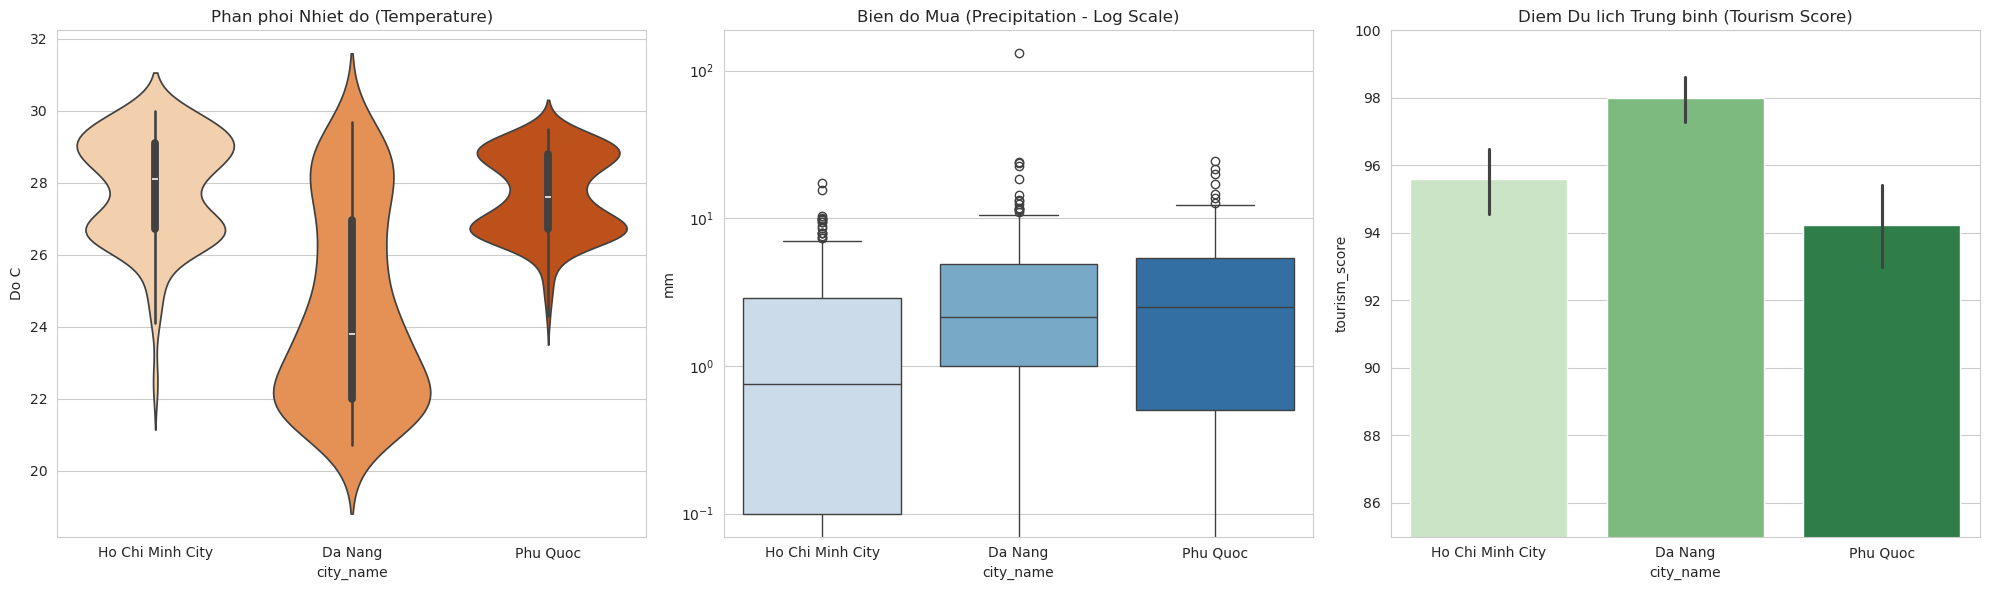


--- BANG THONG KE CHI TIET (Descriptive Statistics) ---
                   temp                                             precip                                           tourism_score                                               
                  count   mean   std   min   25%   50%    75%   max  count  mean    std  min  25%   50%   75%    max         count   mean   std   min    25%    50%    75%    max
city_name                                                                                                                                                                        
Da Nang           182.0  24.51  2.68  20.7  22.0  23.8  26.95  29.7  182.0  4.49  10.37  0.0  1.0  2.15  4.90  131.0         182.0  97.99  4.39  80.0  100.0  100.0  100.0  100.0
Ho Chi Minh City  182.0  27.84  1.50  22.2  26.7  28.1  29.10  30.0  182.0  2.11   3.07  0.0  0.1  0.75  2.90   17.3         182.0  95.60  6.56  80.0   95.0  100.0  100.0  100.0
Phu Quoc          182.0  27.66  1.13  24.3  26.7  27.

In [59]:
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.violinplot(data=df_forecast_weather, x='city_name', y='temp', ax=axes[0], palette='Oranges')
axes[0].set_title('Phan phoi Nhiet do (Temperature)')
axes[0].set_ylabel('Do C')

sns.boxplot(data=df_forecast_weather, x='city_name', y='precip', ax=axes[1], palette='Blues')
axes[1].set_title('Bien do Mua (Precipitation - Log Scale)')
axes[1].set_yscale('log')
axes[1].set_ylabel('mm')

sns.barplot(data=df_forecast_weather, x='city_name', y='tourism_score', ax=axes[2], palette='Greens')
axes[2].set_title('Diem Du lich Trung binh (Tourism Score)')
axes[2].set_ylim(85, 100)

plt.tight_layout()
plt.show()

print("\n--- BANG THONG KE CHI TIET (Descriptive Statistics) ---")
stats_summary = df_forecast_weather.groupby('city_name')[['temp', 'precip', 'tourism_score']].describe().round(2)
print(stats_summary)

Kết quả thống kê mô tả cho ba thành phố Đà Nẵng, TP. Hồ Chí Minh và Phú Quốc cho thấy sự khác biệt rõ rệt về đặc trưng khí hậu và mức độ thuận lợi du lịch.

**Nhiệt độ (temp):**  
TP. Hồ Chí Minh và Phú Quốc có mức nhiệt trung bình năm cao và ổn định hơn (≈27.7–27.8°C) với độ lệch chuẩn thấp, phản ánh đặc trưng khí hậu nhiệt đới gió mùa cận xích đạo. Đà Nẵng có mức nhiệt trung bình thấp hơn đáng kể (≈24.5°C) và độ biến thiên lớn hơn (std=2.68), phản ánh khí hậu miền Trung chịu ảnh hưởng rõ rệt của mùa lạnh.

**Lượng mưa (precip):**  
Đà Nẵng có lượng mưa trung bình cao nhất (mean ≈ 4.49 mm), với giá trị tối đa lên tới 131 mm, cho thấy sự xuất hiện của các đợt mưa lớn theo mùa. Trong khi đó, TP. Hồ Chí Minh và Phú Quốc có lượng mưa trung bình thấp hơn nhưng phân bố ổn định hơn, phù hợp với đặc trưng khí hậu phân mùa rõ rệt giữa mùa khô và mùa mưa.

**Điểm số du lịch (tourism_score):**  
Cả ba thành phố đều duy trì mức điểm du lịch rất cao (mean > 94), trong đó Đà Nẵng dẫn đầu với mức trung bình 97.99. Mức độ ổn định cao (std thấp) cho thấy điều kiện du lịch nhìn chung thuận lợi quanh năm. Những khác biệt nhỏ giữa các thành phố phản ánh đặc tính mùa vụ chứ không phải biến động mạnh về hạ tầng hay sức hấp dẫn du lịch.

Nhìn chung, thống kê mô tả phản ánh sự khác biệt vùng miền về khí hậu và lượng mưa, trong khi mức độ hấp dẫn du lịch duy trì ở mức cao tương đối ổn định cho cả ba địa phương.


### Phân tích Xu hướng Nhiệt độ & Lượng Mưa Theo Tháng

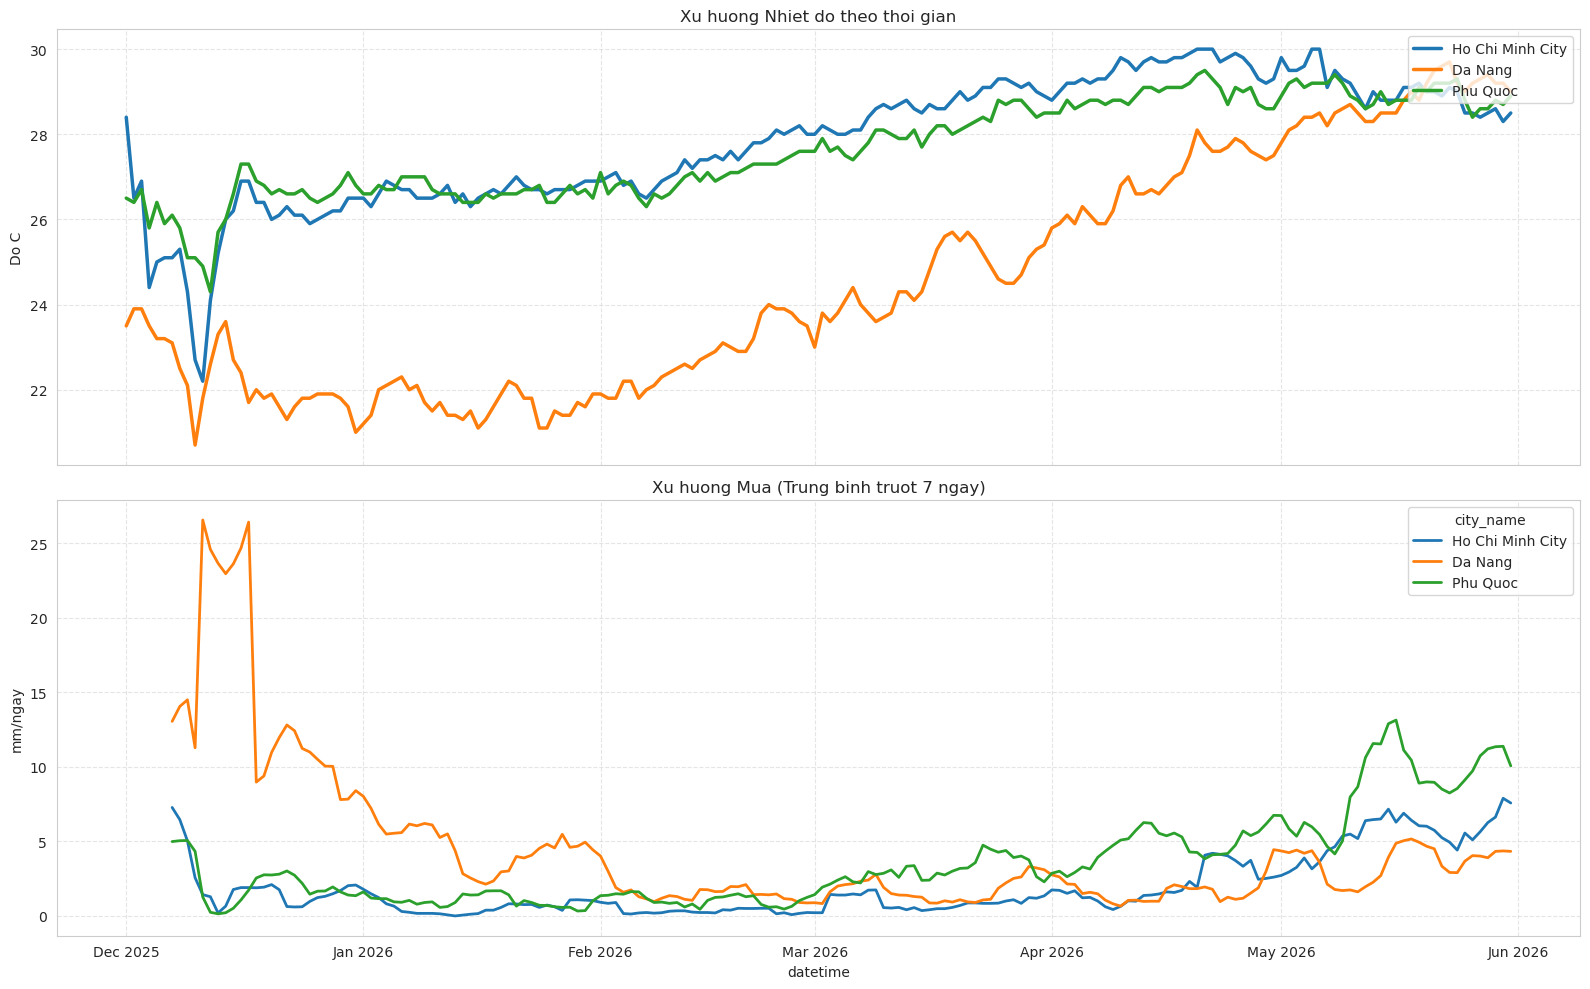


--- THONG KE TRUNG BINH THANG (Monthly Weather Summary) ---
                              temp  precip
city_name        month_year               
Da Nang          2025-12     22.31   426.4
                 2026-01     21.65   131.2
                 2026-02     22.79    36.5
                 2026-03     24.55    57.2
                 2026-04     26.91    62.4
                 2026-05     28.78   103.9
Ho Chi Minh City 2025-12     25.74    83.2
                 2026-01     26.66    15.6
                 2026-02     27.37     8.3
                 2026-03     28.68    31.2
                 2026-04     29.56    66.0
                 2026-05     29.04   180.3
Phu Quoc         2025-12     26.31    72.3
                 2026-01     26.65    33.0
                 2026-02     27.01    29.6
                 2026-03     28.10    95.3
                 2026-04     28.91   155.9
                 2026-05     28.95   273.9


In [60]:
import matplotlib.dates as mdates

df_forecast_weather['datetime'] = pd.to_datetime(
    df_forecast_weather['datetime'],
    errors='coerce'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(data=df_forecast_weather, x='datetime', y='temp',
             hue='city_name', palette='tab10', linewidth=2.5, ax=ax1)
ax1.set_title('Xu huong Nhiet do theo thoi gian')
ax1.set_ylabel('Do C')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

df_plot = df_forecast_weather.sort_values('datetime').copy()
df_plot['precip_smooth'] = df_plot.groupby('city_name')['precip'].transform(lambda x: x.rolling(7).mean())

sns.lineplot(data=df_plot, x='datetime', y='precip_smooth',
             hue='city_name', palette='tab10', linewidth=2, ax=ax2)
ax2.set_title('Xu huong Mua (Trung binh truot 7 ngay)')
ax2.set_ylabel('mm/ngay')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n--- THONG KE TRUNG BINH THANG (Monthly Weather Summary) ---")
df_forecast_weather['month_year'] = df_forecast_weather['datetime'].dt.to_period('M')
monthly_stats = df_forecast_weather.groupby(['city_name', 'month_year'])[['temp', 'precip']].agg(
    {'temp': 'mean', 'precip': 'sum'}
).round(2)
print(monthly_stats)

Kết quả tổng hợp theo `month_year` cho thấy chu kỳ khí hậu theo mùa của ba thành phố được thể hiện rất rõ.

**Đà Nẵng:**  
Nhiệt độ tăng dần từ tháng 1 (≈21.6°C) đến tháng 5 (≈28.8°C), thể hiện giai đoạn chuyển từ mùa lạnh sang mùa nóng. Lượng mưa giảm mạnh từ giai đoạn mưa lớn cuối năm (426 mm trong 12/2025) xuống mức thấp trong tháng 2–4, trước khi tăng trở lại vào tháng 5, phản ánh đặc trưng mùa khô ngắn và mùa mưa kéo dài của miền Trung.

**TP. Hồ Chí Minh:**  
Nhiệt độ duy trì ổn định quanh 26.5–29.5°C, gần như không có biến động lớn. Lượng mưa rất thấp trong tháng 1–2 (≈8–15 mm), đúng với giai đoạn cao điểm mùa khô. Bắt đầu từ tháng 4–5, lượng mưa tăng rõ rệt (66–180 mm), đánh dấu sự chuyển sang mùa mưa.

**Phú Quốc:**  
Nhiệt độ tương đối ổn định, dao động nhỏ quanh 26.3–28.95°C. Lượng mưa thấp trong tháng 1–2 (≈30 mm), nhưng tăng mạnh vào tháng 4–5, đặc biệt tháng 5 đạt gần 274 mm – phản ánh sự ảnh hưởng rõ rệt của gió mùa Tây Nam.

Nhìn chung, dữ liệu theo tháng cho thấy chu kỳ khí hậu theo mùa rất rõ:  
- **Đà Nẵng:** Biến thiên mạnh, mùa mưa – mùa khô khác biệt rõ.  
- **HCM & Phú Quốc:** Ổn định hơn, mùa mưa bắt đầu mạnh từ tháng 5.  
Các xu hướng này là cơ sở quan trọng để mô hình hóa sự ảnh hưởng của khí hậu lên nhu cầu du lịch và giá dịch vụ.


### Phân tích Điểm Số Du Lịch

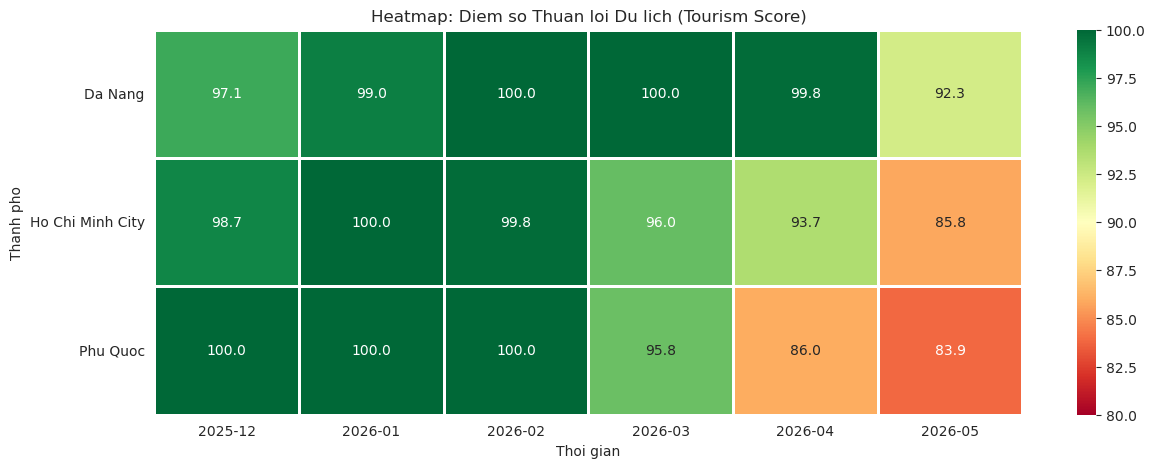


--- MA TRAN DIEM SO DU LICH (Tourism Score Matrix) ---
month_year        2025-12  2026-01  2026-02  2026-03  2026-04  2026-05
city_name                                                             
Da Nang             97.10    99.03   100.00   100.00    99.83    92.26
Ho Chi Minh City    98.71   100.00    99.82    95.97    93.67    85.81
Phu Quoc           100.00   100.00   100.00    95.81    86.00    83.87


In [61]:
pivot_score = df_forecast_weather.pivot_table(
    index='city_name',
    columns='month_year',
    values='tourism_score',
    aggfunc='mean'
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_score, annot=True, cmap='RdYlGn', fmt=".1f",
            linewidths=1, linecolor='white', vmin=80, vmax=100)

plt.title('Heatmap: Diem so Thuan loi Du lich (Tourism Score)')
plt.xlabel('Thoi gian')
plt.ylabel('Thanh pho')
plt.yticks(rotation=0)
plt.show()

print("\n--- MA TRAN DIEM SO DU LICH (Tourism Score Matrix) ---")
print(pivot_score.round(2))

Ma trận điểm số du lịch theo thành phố và tháng cho thấy mức độ hấp dẫn du lịch khá cao quanh năm nhưng có sự khác biệt theo mùa giữa ba địa phương.

**Đà Nẵng:**  
Duy trì điểm số gần như tuyệt đối từ tháng 1 đến tháng 4 (≈99–100). Tuy nhiên, tháng 5 giảm còn 92.26 do bắt đầu bước vào giai đoạn giao mùa, có khả năng xuất hiện nắng nóng hoặc mưa trái mùa, ảnh hưởng đến mức độ tiện lợi du lịch.

**TP. Hồ Chí Minh:**  
Có mức điểm rất cao trong tháng 12 và tháng 1 (≈98.7–100), phù hợp với thời gian khô ráo, thời tiết dễ chịu. Điểm số giảm nhẹ qua các tháng tiếp theo (≈85.8 vào tháng 5), tương ứng với sự gia tăng lượng mưa đầu mùa.

**Phú Quốc:**  
Là địa phương có điểm du lịch cao nhất trong mùa đông (100% vào tháng 12–2), là thời điểm biển đẹp, thời tiết khô ráo – đúng với giai đoạn cao điểm du lịch đảo. Tuy nhiên điểm số giảm dần từ tháng 3 đến tháng 5 (≈83.9 tháng 5), trùng với thời kỳ biển động và bắt đầu mùa mưa.

Các kết quả này cho thấy mức độ nổi bật của từng thành phố theo mùa:  
- **Phú Quốc:** Đỉnh điểm vào mùa đông, giảm mạnh khi vào mùa mưa.  
- **Đà Nẵng:** Ổn định vào mùa khô, bắt đầu giảm khi tăng độ ẩm và nhiệt độ tháng 5.  
- **HCM:** Tương đối ổn định, nhưng ảnh hưởng mạnh bởi chuyển mùa sang mùa mưa.

Đây là cơ sở quan trọng để dự báo nhu cầu khách du lịch theo thời gian và tối ưu chiến lược định giá hoặc quảng bá theo mùa.
